<a href="https://www.kaggle.com/code/mh0386/car-price-prediction" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# [Presentation](https://tome.app/mh0386/revving-up-the-future-ai-powered-used-car-price-predictions-clgtjqlbx17hp1u41lb7yr442)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from kagglehub import dataset_download
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.utils import shuffle

/home/mohamed/Dev/notebooks/.devenv/state/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

## Read Data

In [ ]:
data = pd.read_csv(f'{dataset_download("aishwaryamuthukumar/cars-dataset-audi-bmw-ford-hyundai-skoda-vw")}/cars_dataset.csv')
data

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0.0,78.4,1.6,Hyundai
72431,I40,2015,7830,Manual,59508,Diesel,30.0,65.7,1.7,Hyundai
72432,I10,2017,6830,Manual,13810,Petrol,20.0,60.1,1.0,Hyundai
72433,Tucson,2018,13994,Manual,23313,Petrol,145.0,44.8,1.6,Hyundai


## Info

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  object 
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  object 
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  object 
 6   tax           72435 non-null  float64
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 5.5+ MB


## Describe

In [4]:
data.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16580.158708,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.028754,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


## Nulls

In [5]:
data.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

## Data Columns

In [6]:
data.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'Make'],
      dtype='object')

# Draw

## Pies

([<matplotlib.patches.Wedge at 0x786560e7a260>,
 [Text(-0.7729190238785778, 0.7826852384749482, 'audi'),
  Text(-0.8791279474462104, -0.6611611392232708, 'BMW'),
  Text(0.21744407085864373, -1.0782940582459042, 'Ford'),
  Text(0.9945038467672106, -0.4700660578740191, 'vw'),
  Text(1.0464272560462269, 0.3391017514014995, 'toyota'),
  Text(0.7030505330979441, 0.8460023332773362, 'skoda'),
  Text(0.23014940052000027, 1.0756538725074551, 'Hyundai')],
 [Text(-0.4215921948428606, 0.42691922098633533, '24.8%'),
  Text(-0.47952433497066016, -0.3606333486672386, '20.9%'),
  Text(0.11860585683198746, -0.5881603954068567, '14.9%'),
  Text(0.5424566436912057, -0.25639966793128316, '14.7%'),
  Text(0.5707785032979419, 0.18496459167354515, '9.3%'),
  Text(0.3834821089625149, 0.46145581815127423, '8.7%'),
  Text(0.12553603664727286, 0.5867202940949755, '6.7%')])

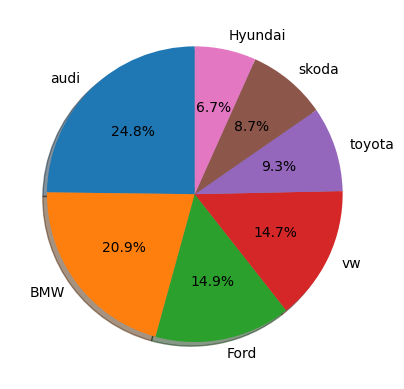

In [7]:
plt.pie(data.Make.value_counts(), labels=data.Make.unique(), autopct='%1.1f%%', shadow=True, startangle=90)

([<matplotlib.patches.Wedge at 0x78655edd4d60>,
 [Text(-1.0524580604173153, -0.3198937809064487, 'Manual'),
  Text(1.046117943928162, -0.34005477116416816, 'Automatic'),
  Text(0.6297383076262443, 0.9019033561906918, 'Semi-Auto'),
  Text(0.00019084556567010798, 1.0999999834445318, 'Other')],
 [Text(-0.5740680329548992, -0.17448751685806294, '59.4%'),
  Text(0.5706097875971793, -0.1854844206350008, '21.2%'),
  Text(0.34349362234158776, 0.49194728519492276, '19.4%'),
  Text(0.00010409758127460434, 0.5999999909697445, '0.0%')])

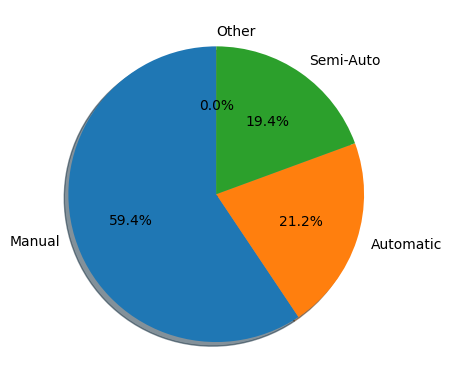

In [8]:
plt.pie(data.transmission.value_counts(), labels=data.transmission.unique(), autopct='%1.1f%%', shadow=True,
        startangle=90)

([<matplotlib.patches.Wedge at 0x78655ee35330>,
 [Text(-1.082208573865754, -0.1970395966587701, 'Petrol'),
  Text(1.0989541655252288, 0.04795562610109356, 'Diesel'),
  Text(0.1611961656975962, 1.0881248991565229, 'Hybrid'),
  Text(0.011878989475678961, 1.0999358570430535, 'Other'),
  Text(0.00023839121722803213, 1.0999999741680122, 'Electric')],
 [Text(-0.5902955857449568, -0.1074761436320564, '55.7%'),
  Text(0.599429544831943, 0.02615761423696012, '39.9%'),
  Text(0.08792518128959792, 0.5935226722671942, '4.0%'),
  Text(0.006479448804915796, 0.5999650129325746, '0.3%'),
  Text(0.00013003157303347206, 0.5999999859098248, '0.0%')])

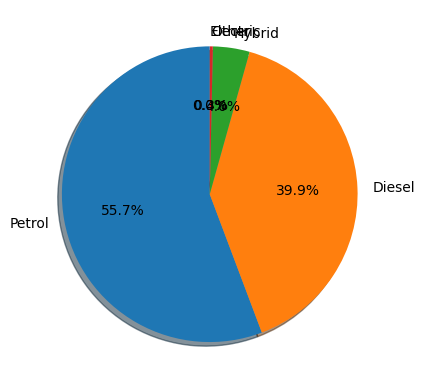

In [9]:
plt.pie(data.fuelType.value_counts(), labels=data.fuelType.unique(), autopct='%1.1f%%', shadow=True, startangle=90)

## Compares

In [10]:
colors = ['#101907', '#314c17', '#63992e', '#95e545', '#aeff5e', '#c0ff82', '#dbffb7']

<AxesSubplot: xlabel='transmission', ylabel='count'>

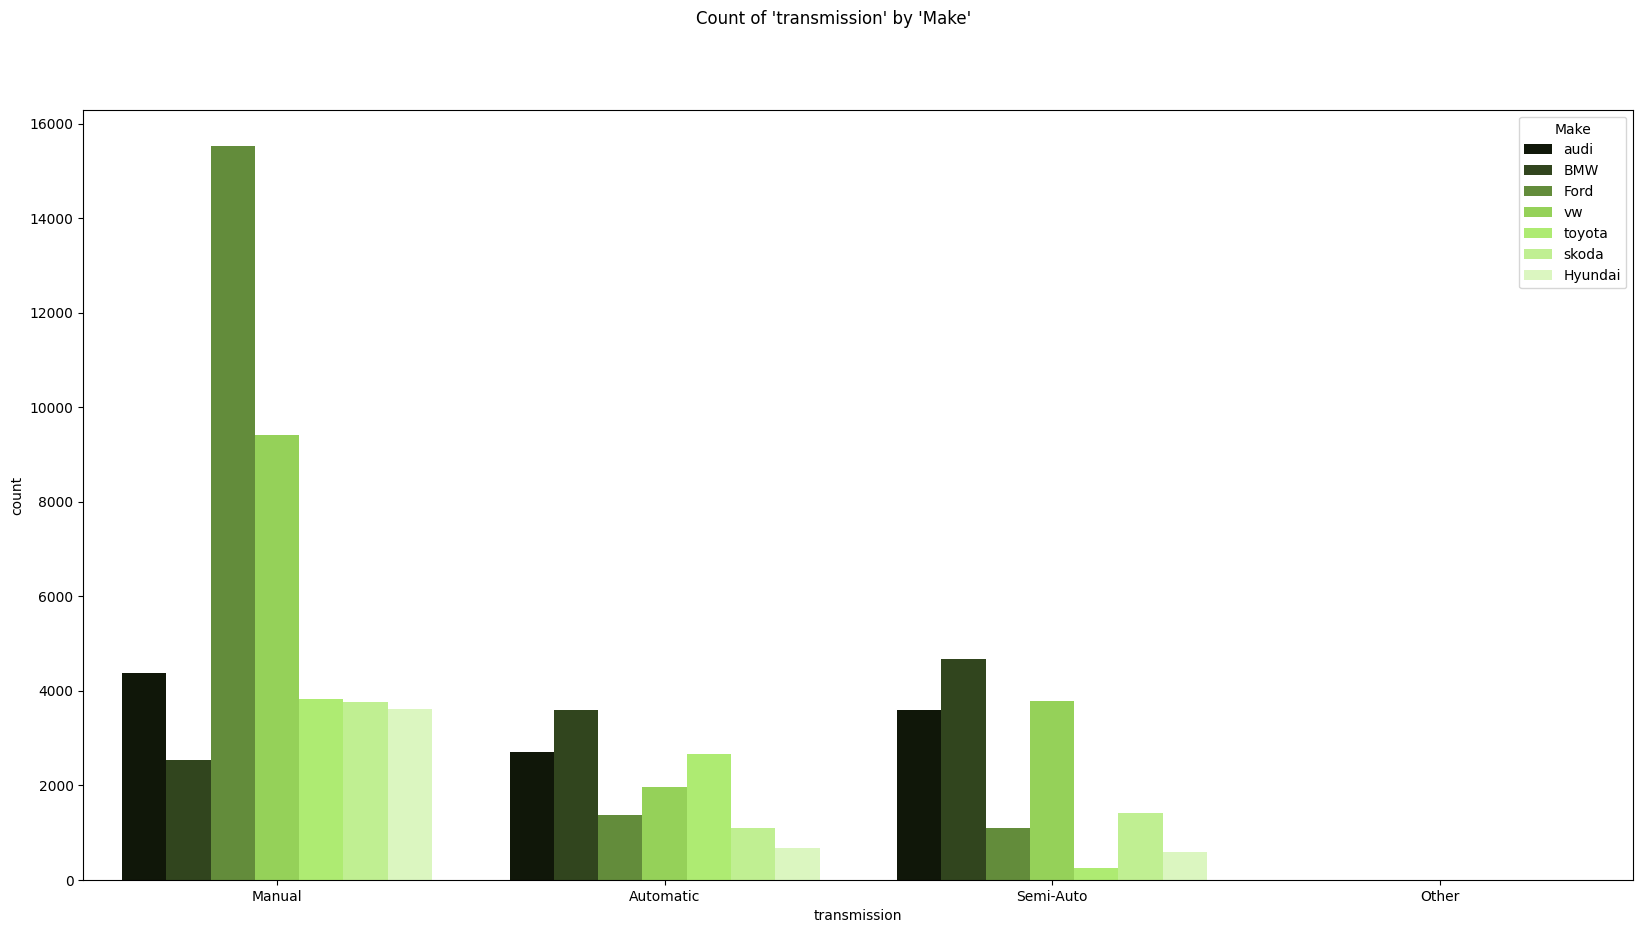

In [11]:
plt.figure(figsize=(20, 10))
plt.suptitle("Count of 'transmission' by 'Make'")
sns.countplot(data=data, x='transmission', hue='Make', palette=colors)

<AxesSubplot: xlabel='fuelType', ylabel='count'>

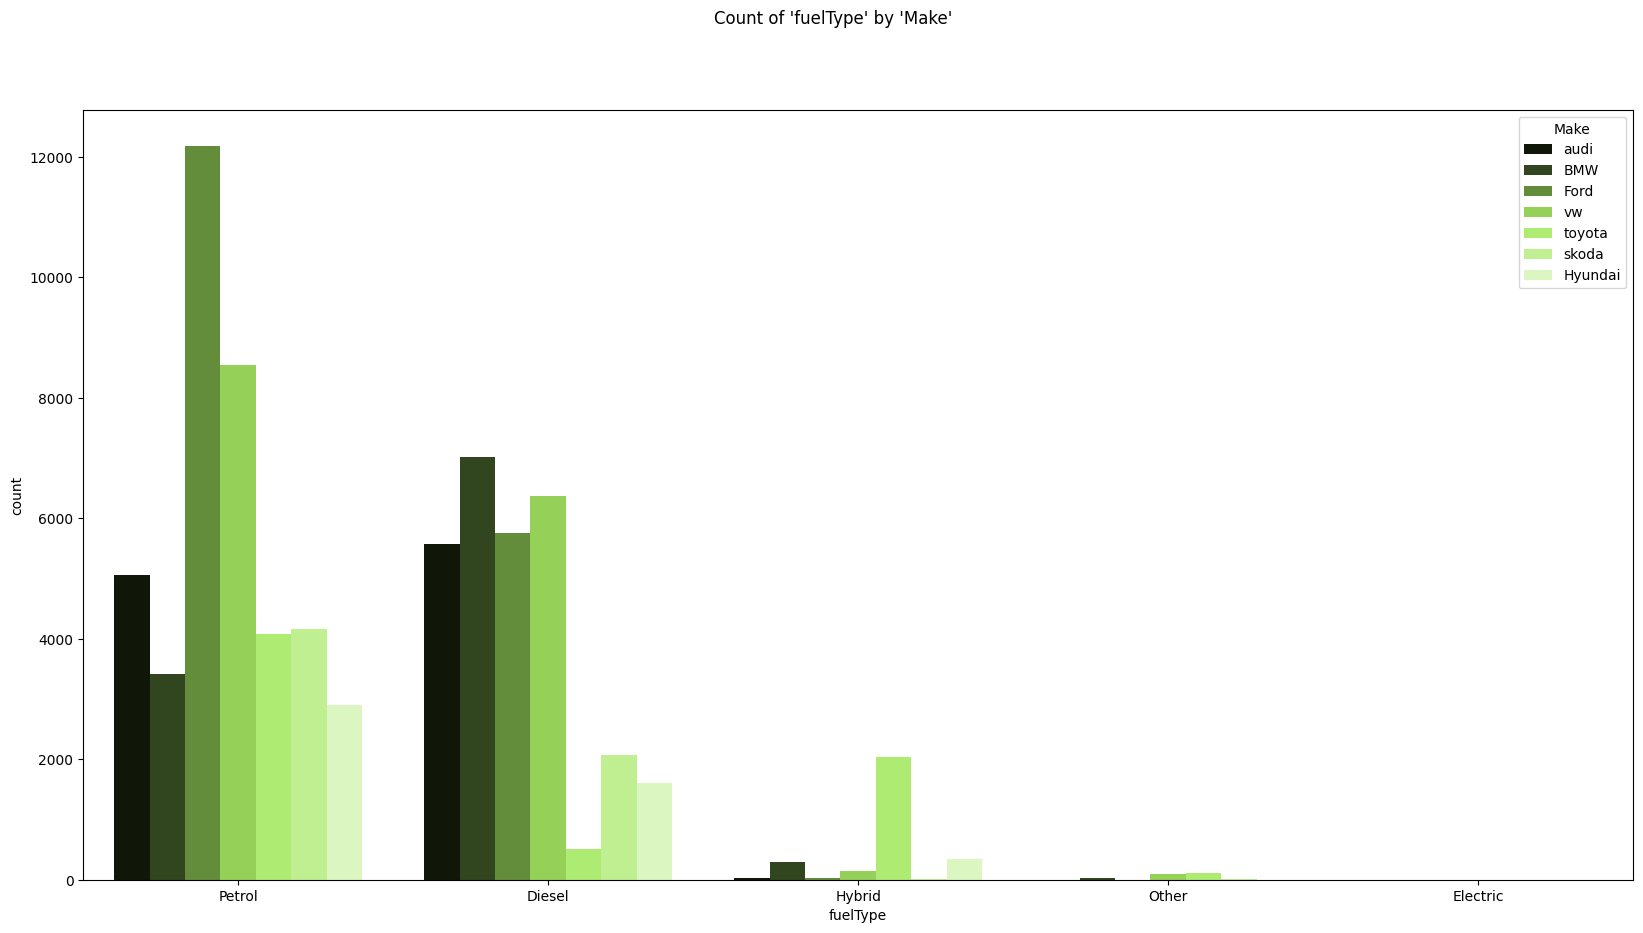

In [12]:
plt.figure(figsize=(20, 10))
plt.suptitle("Count of 'fuelType' by 'Make'")
sns.countplot(data=data, x='fuelType', hue='Make', palette=colors)

## Histograms

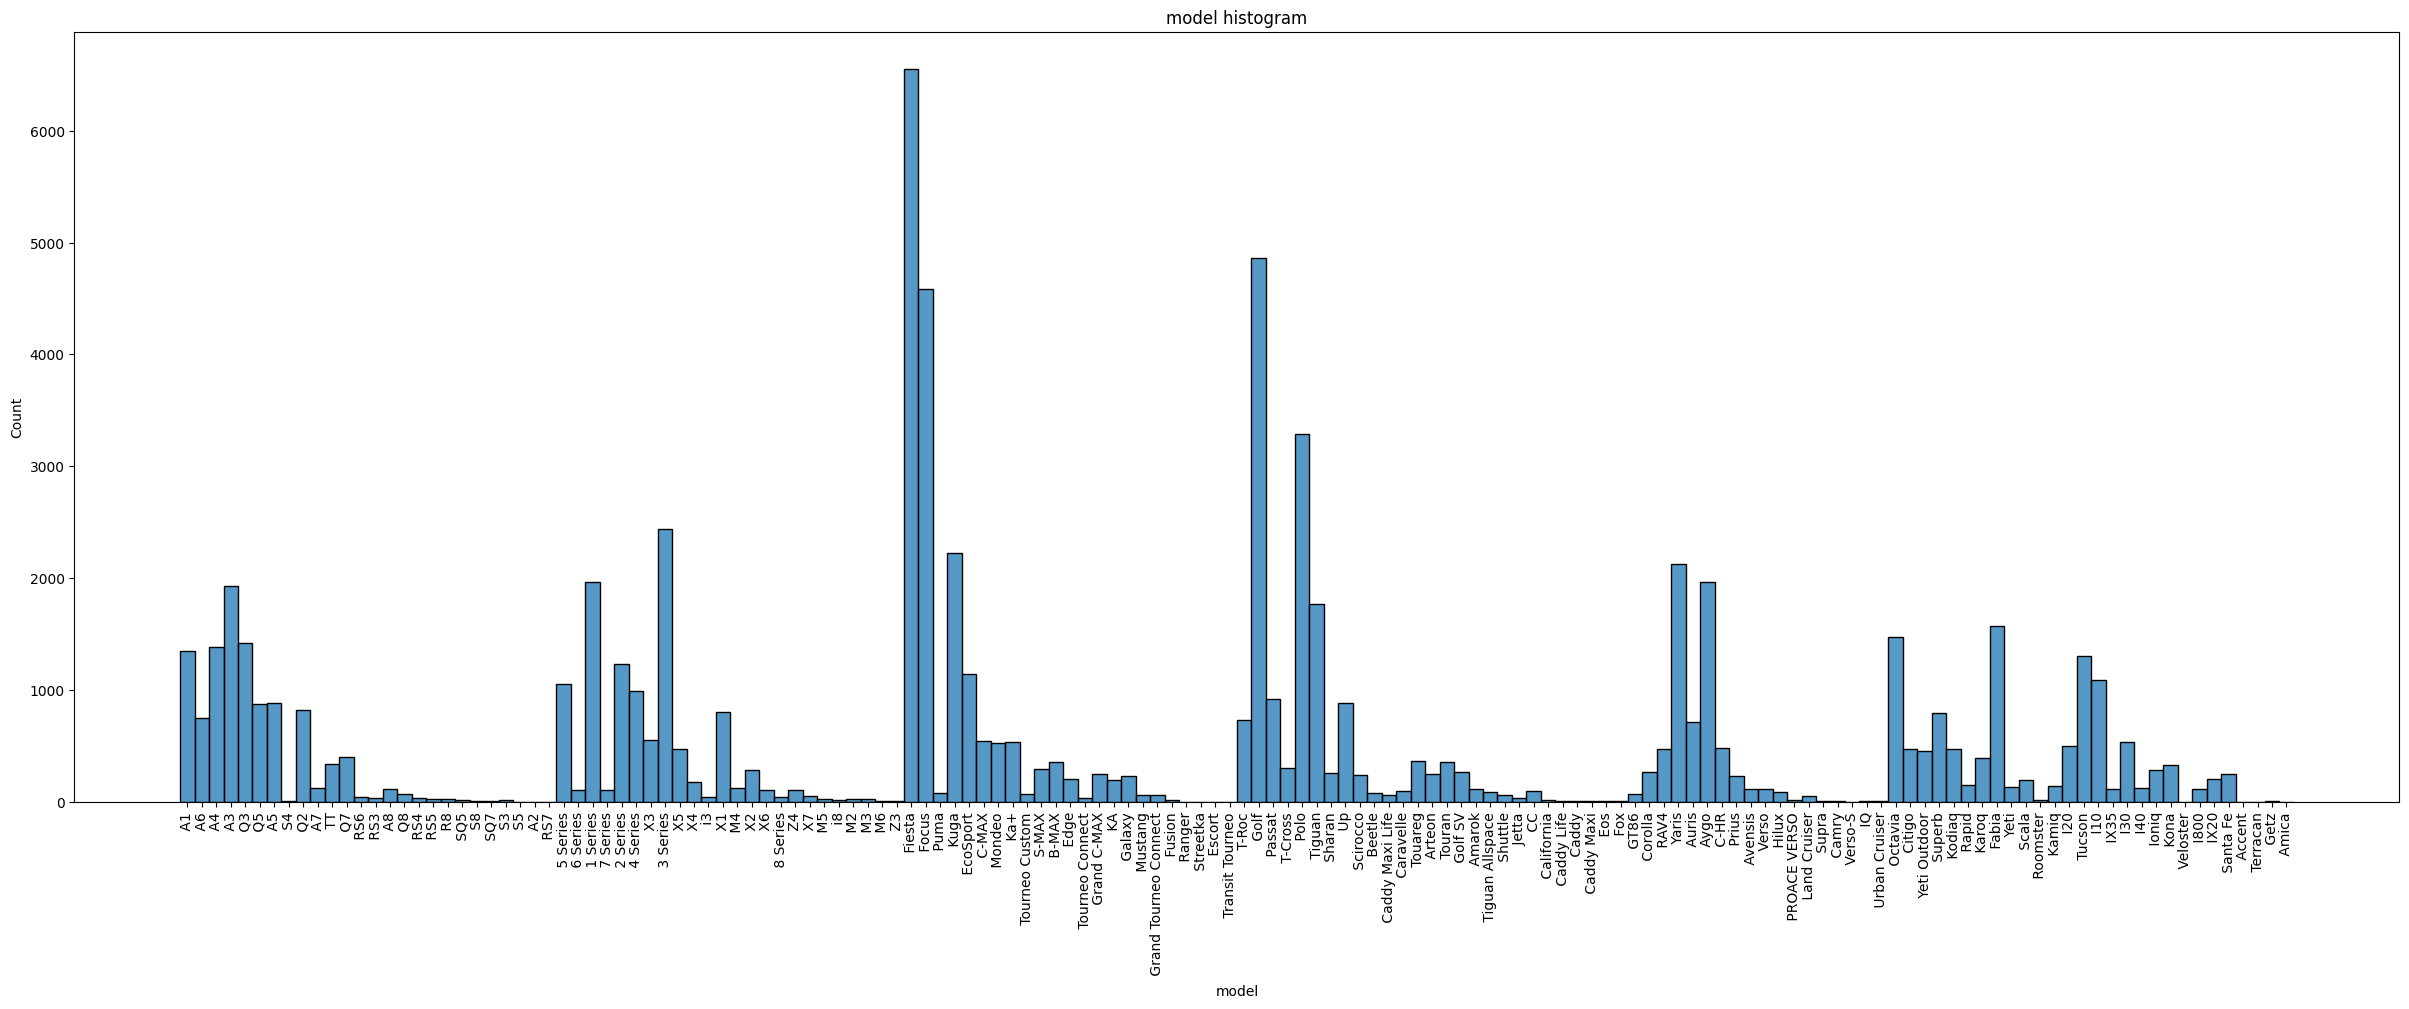

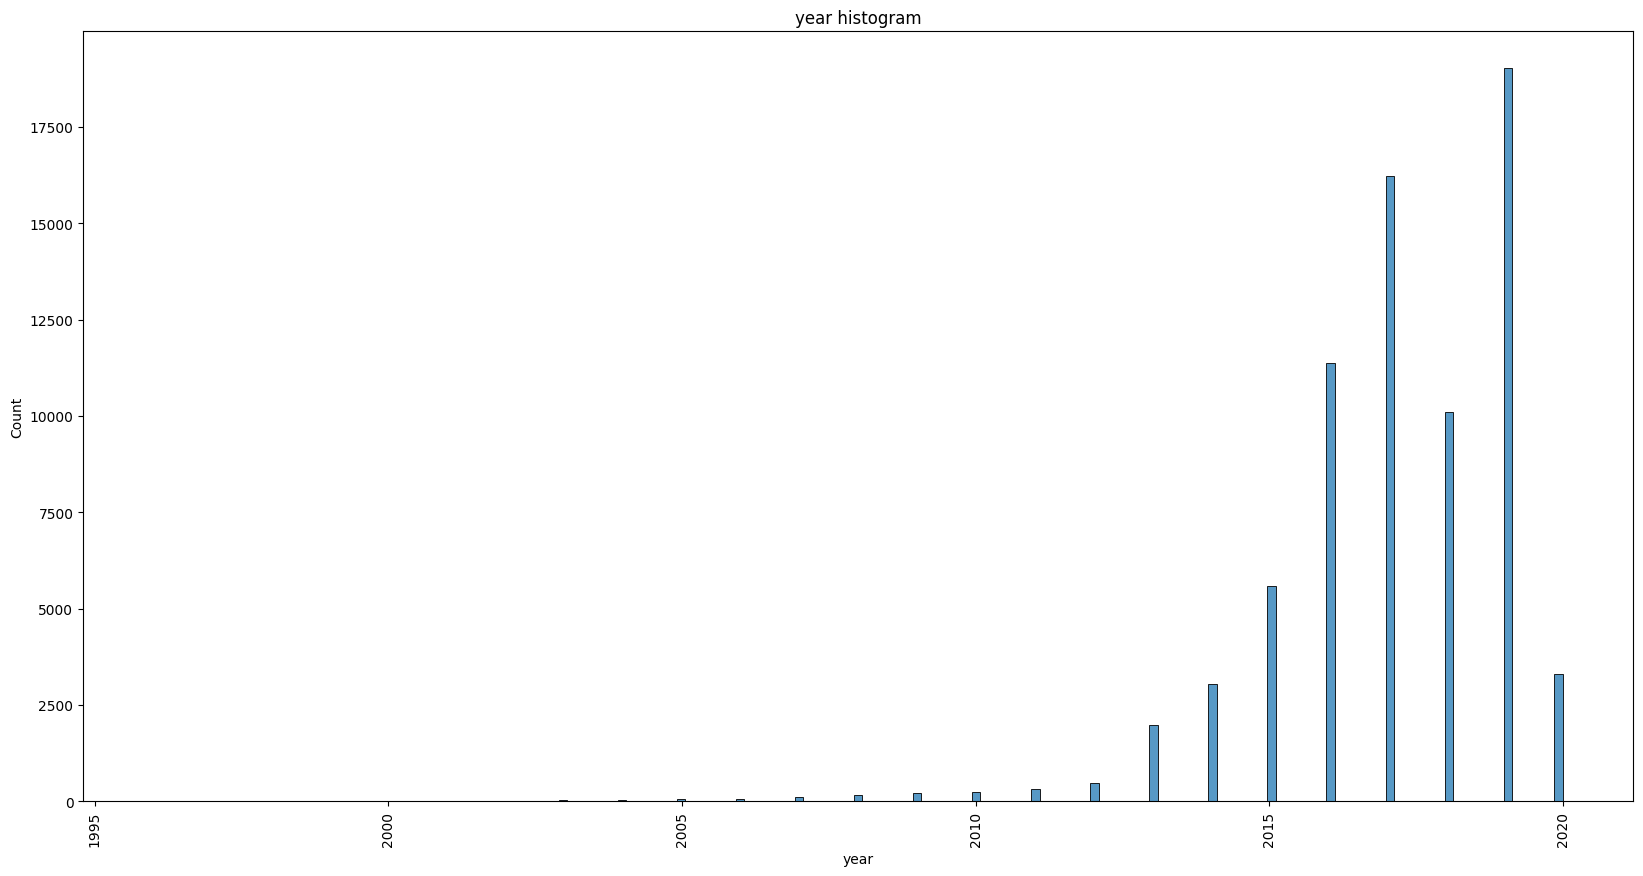

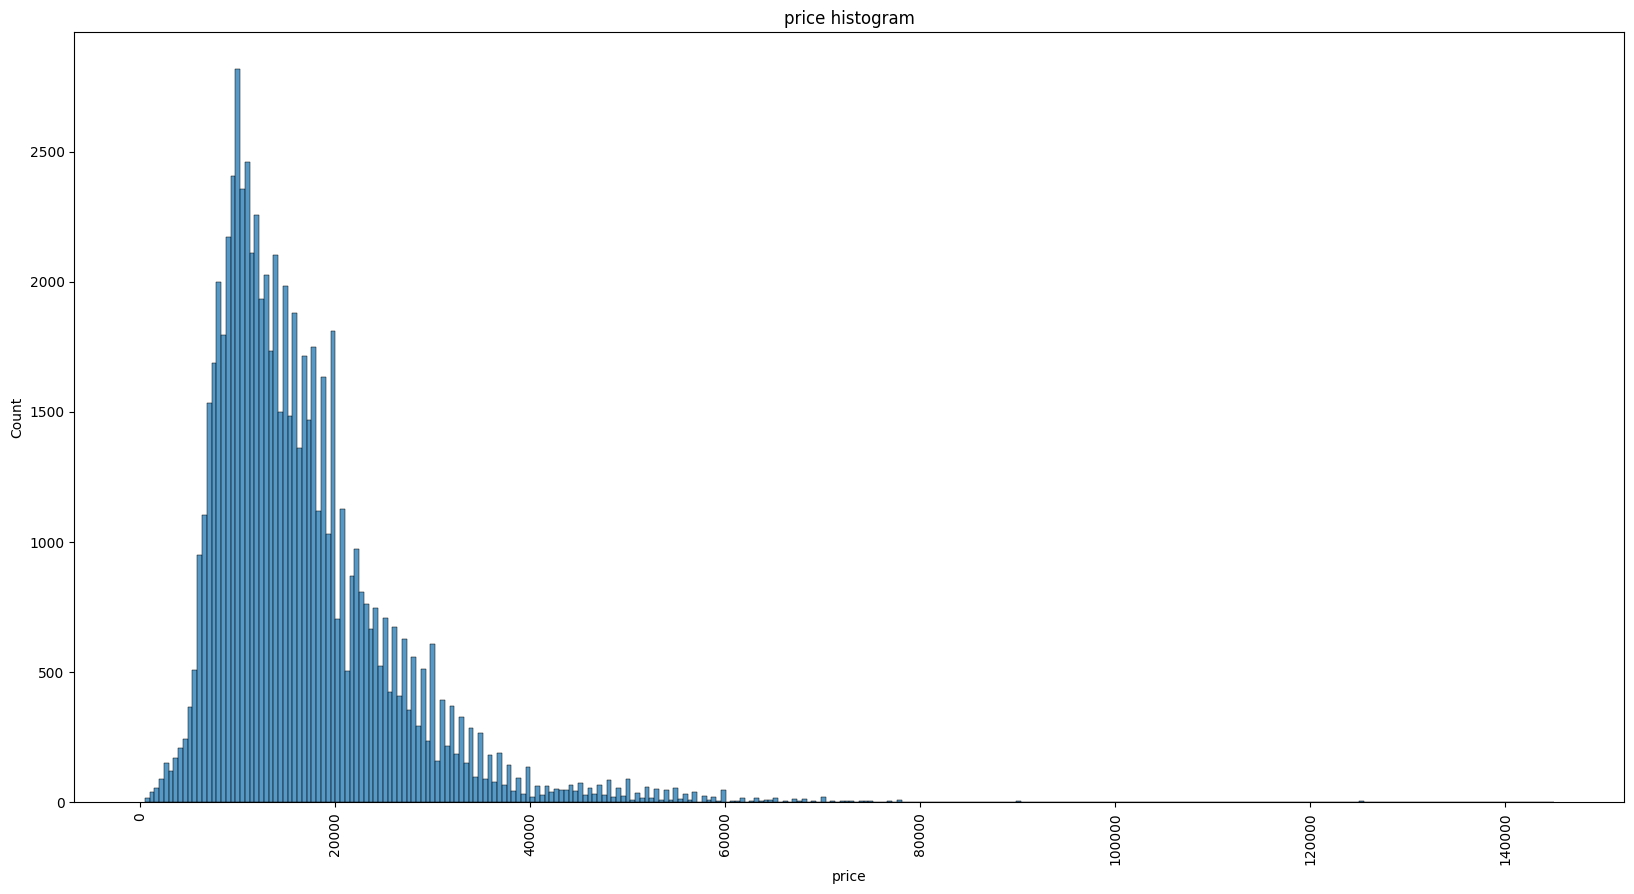

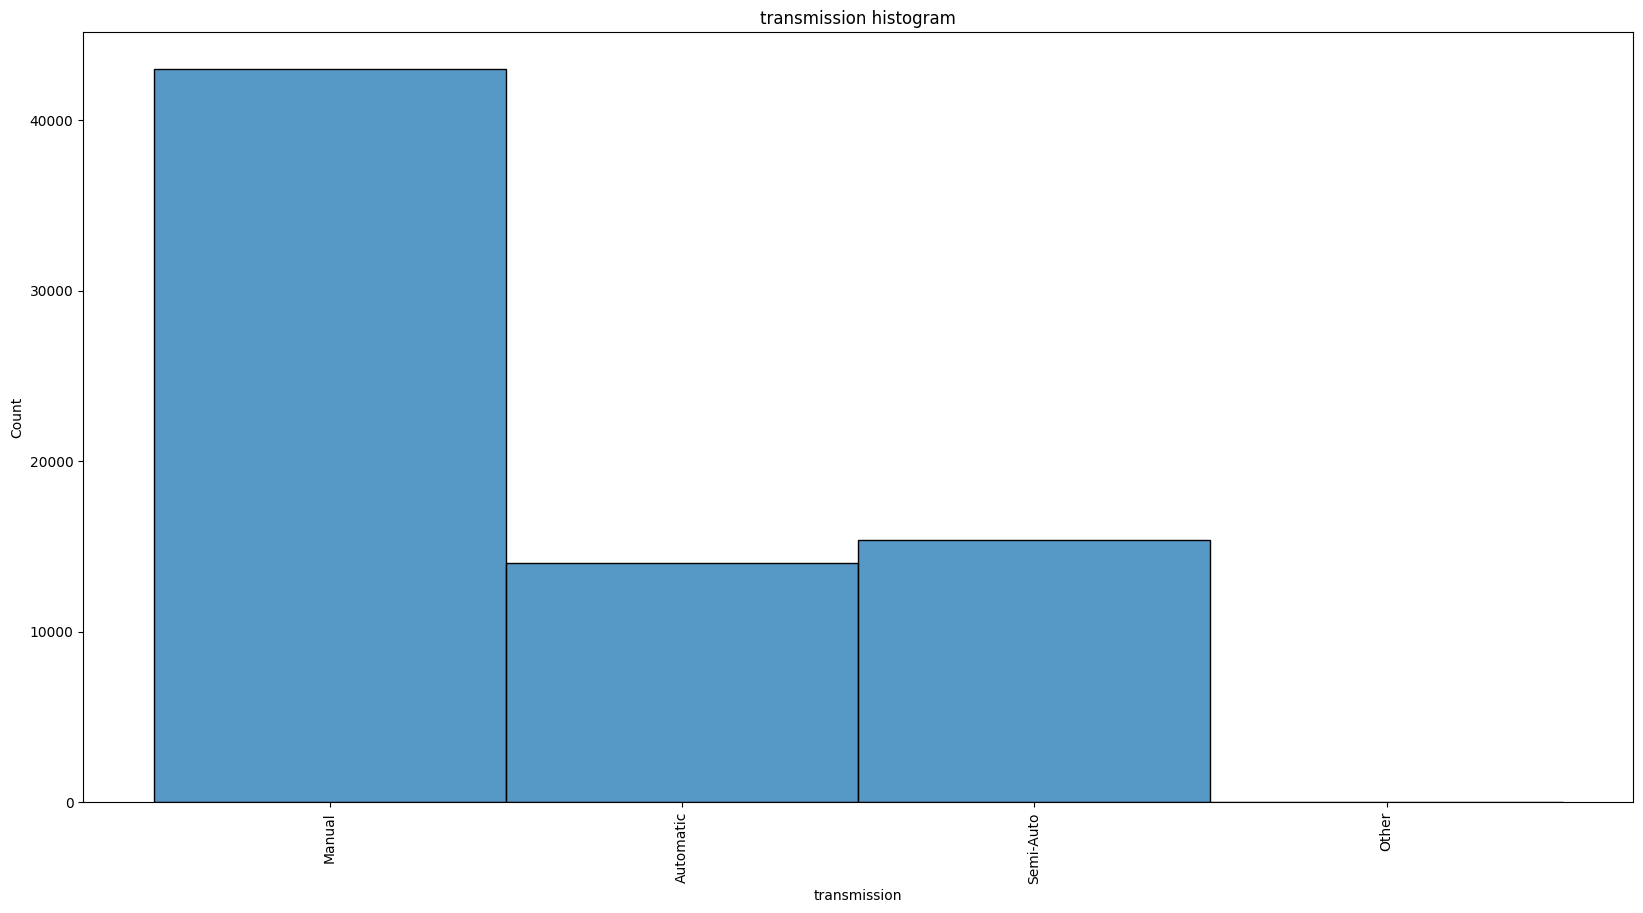

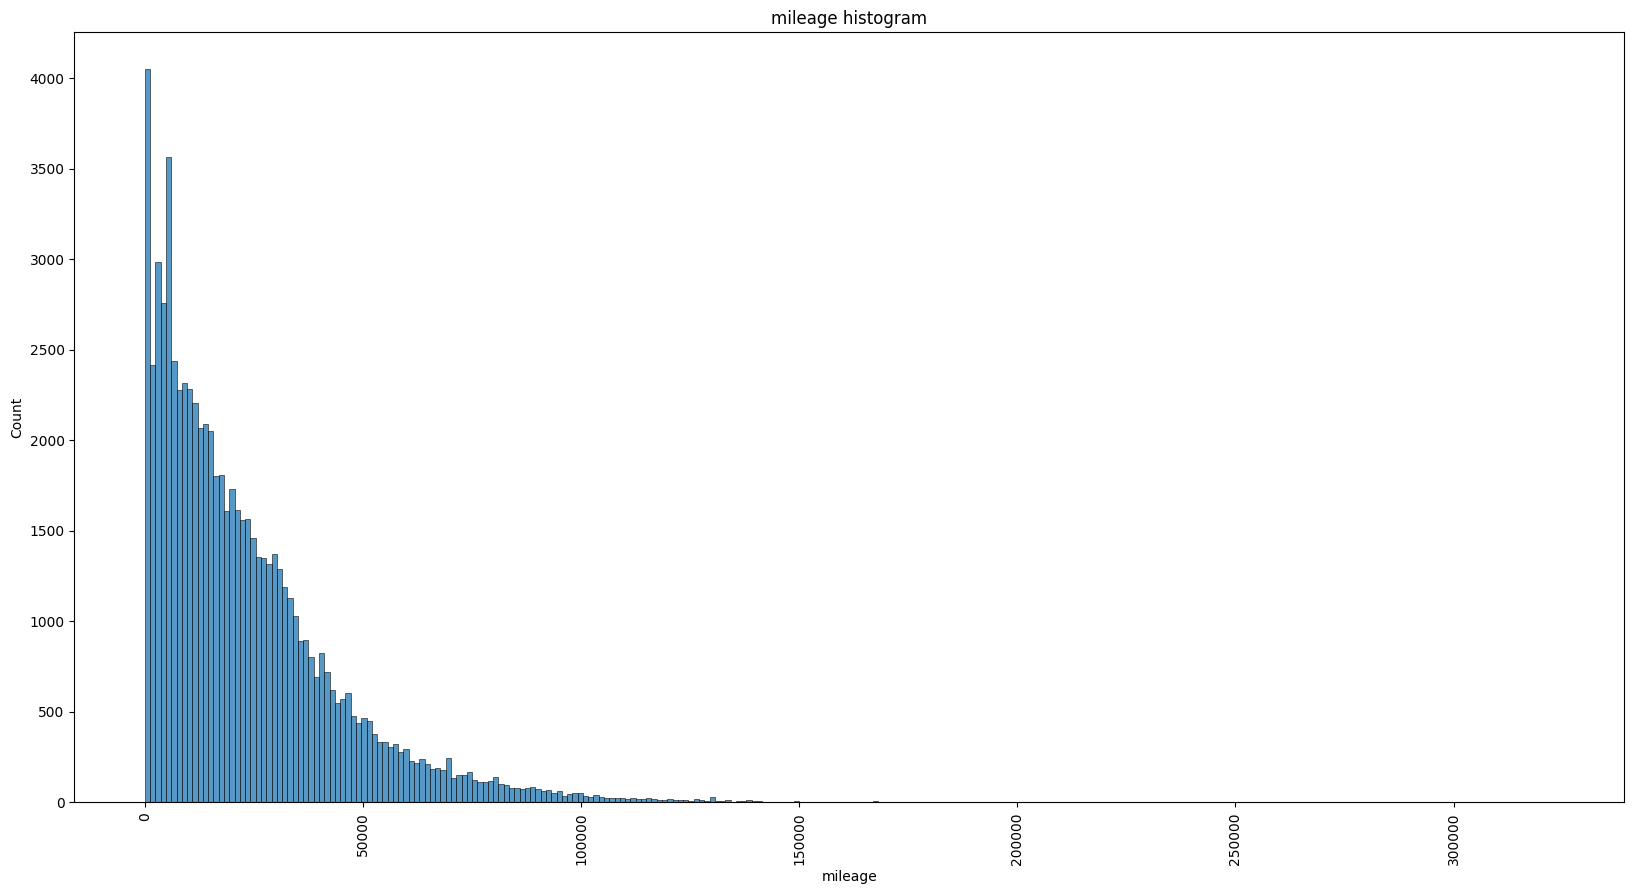

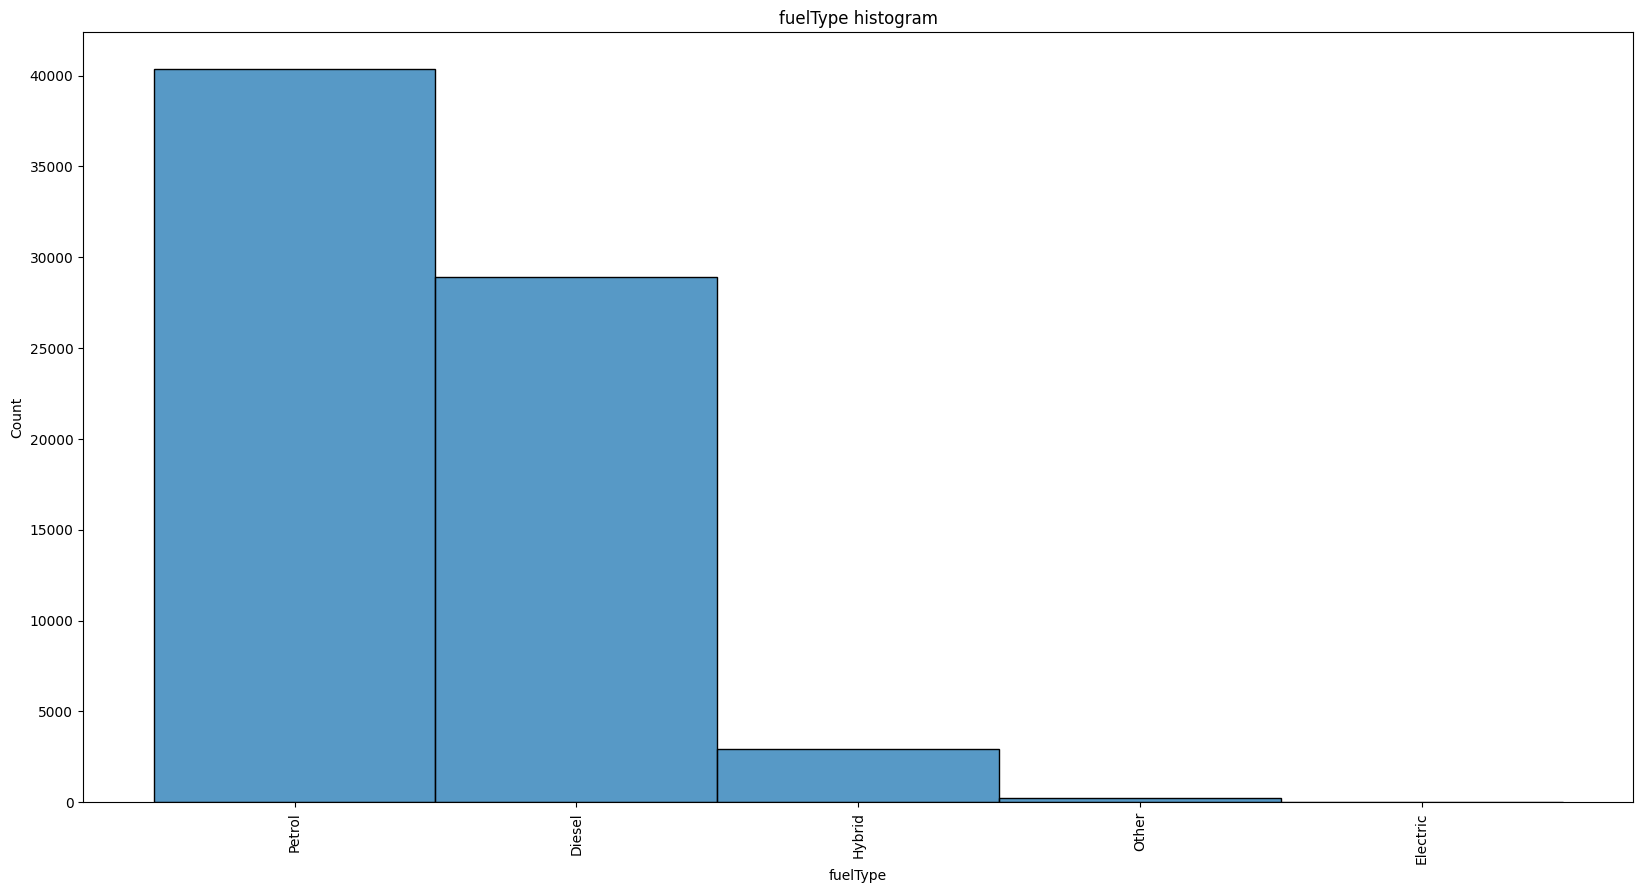

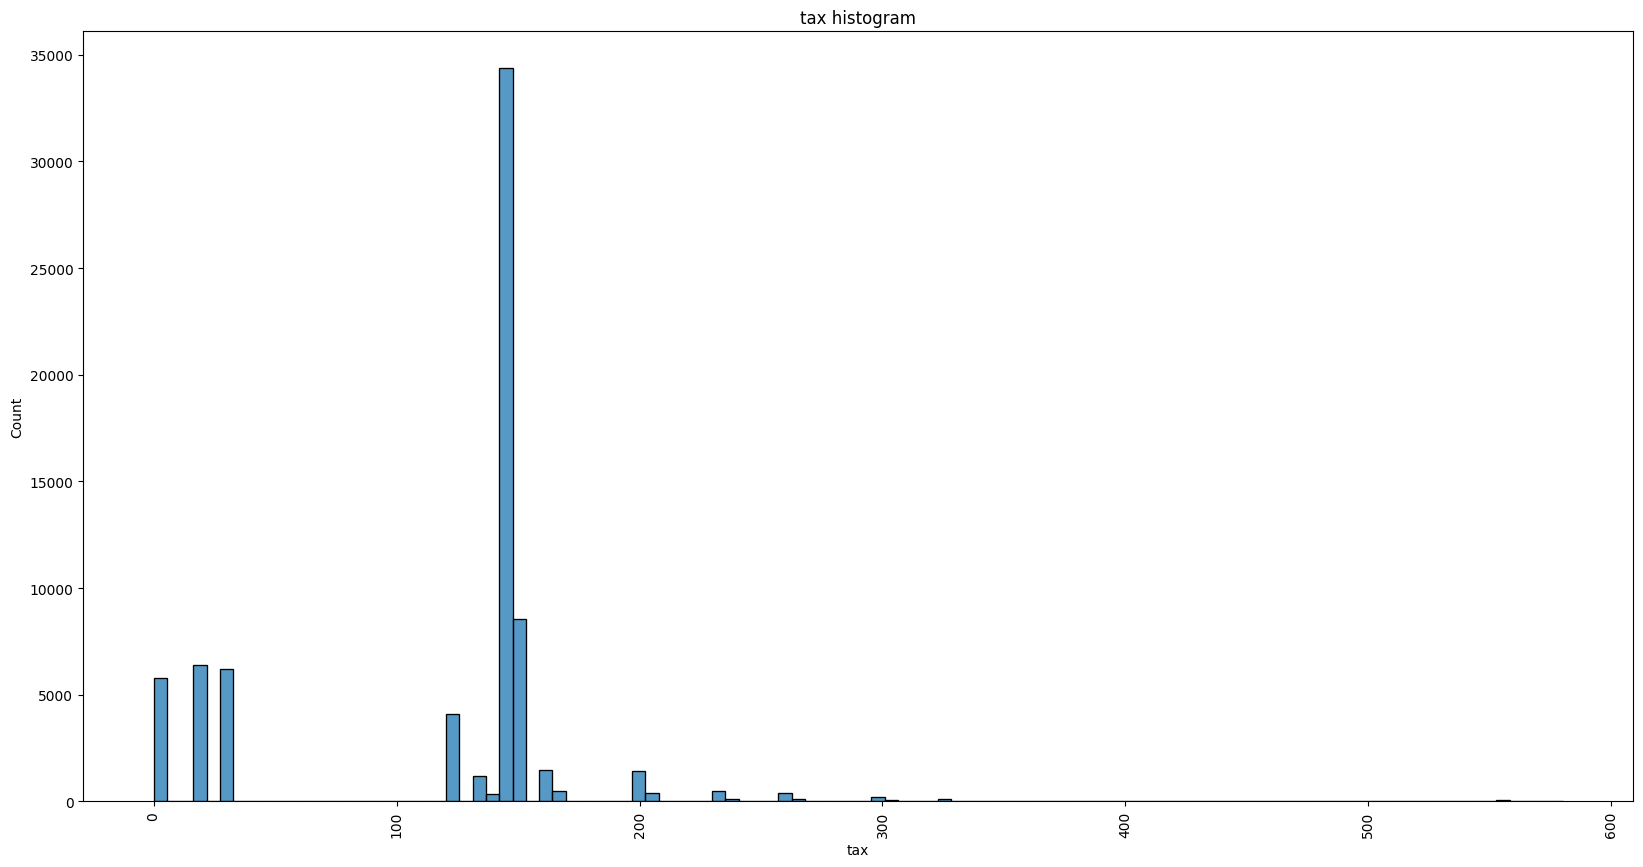

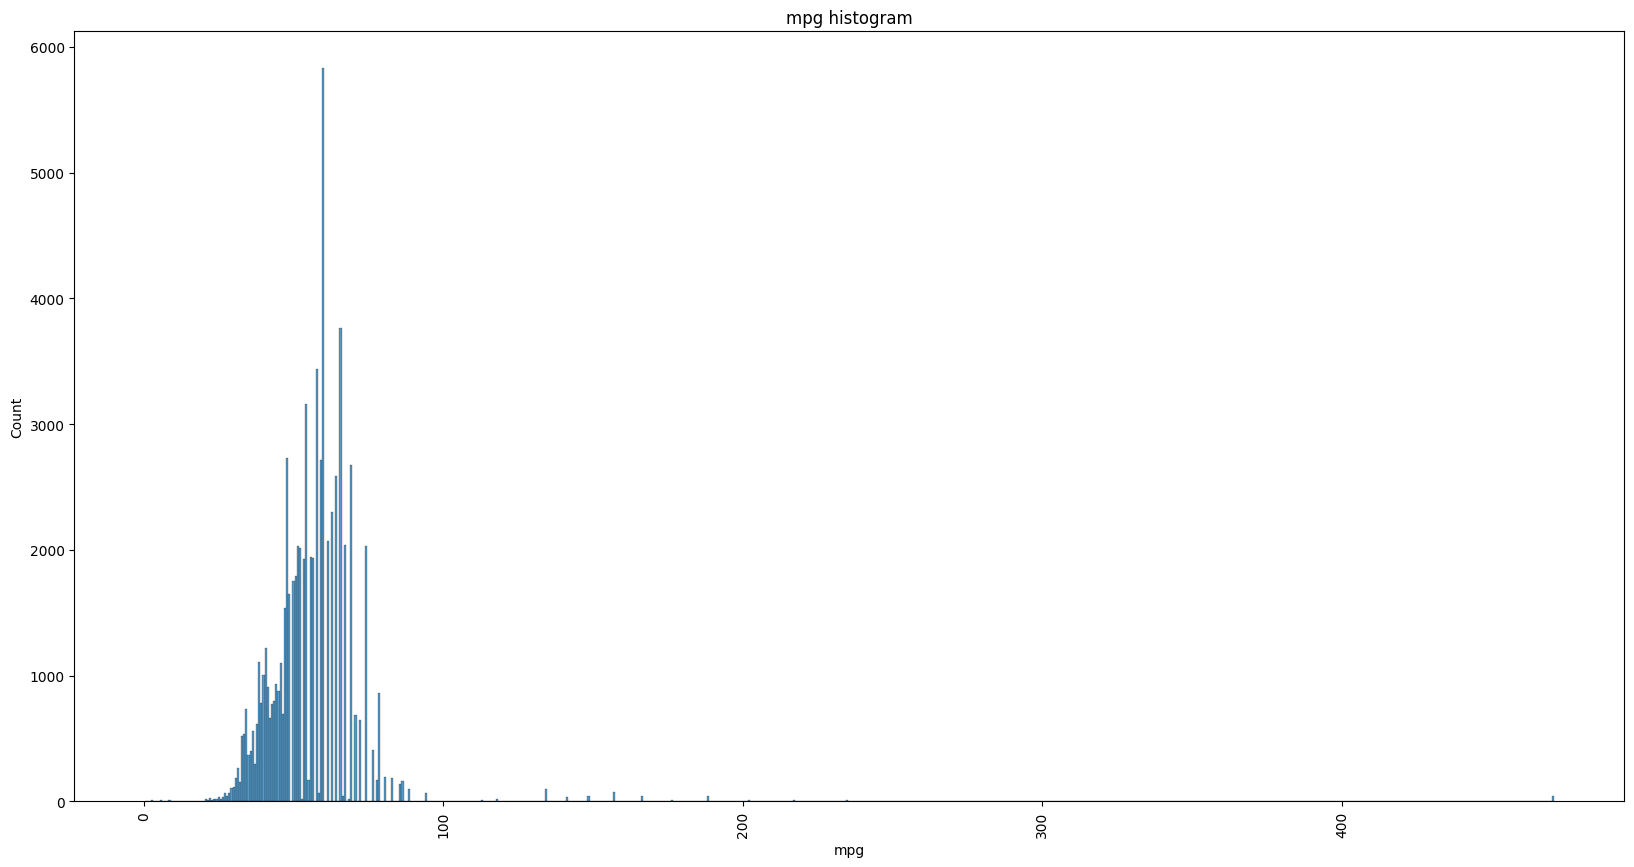

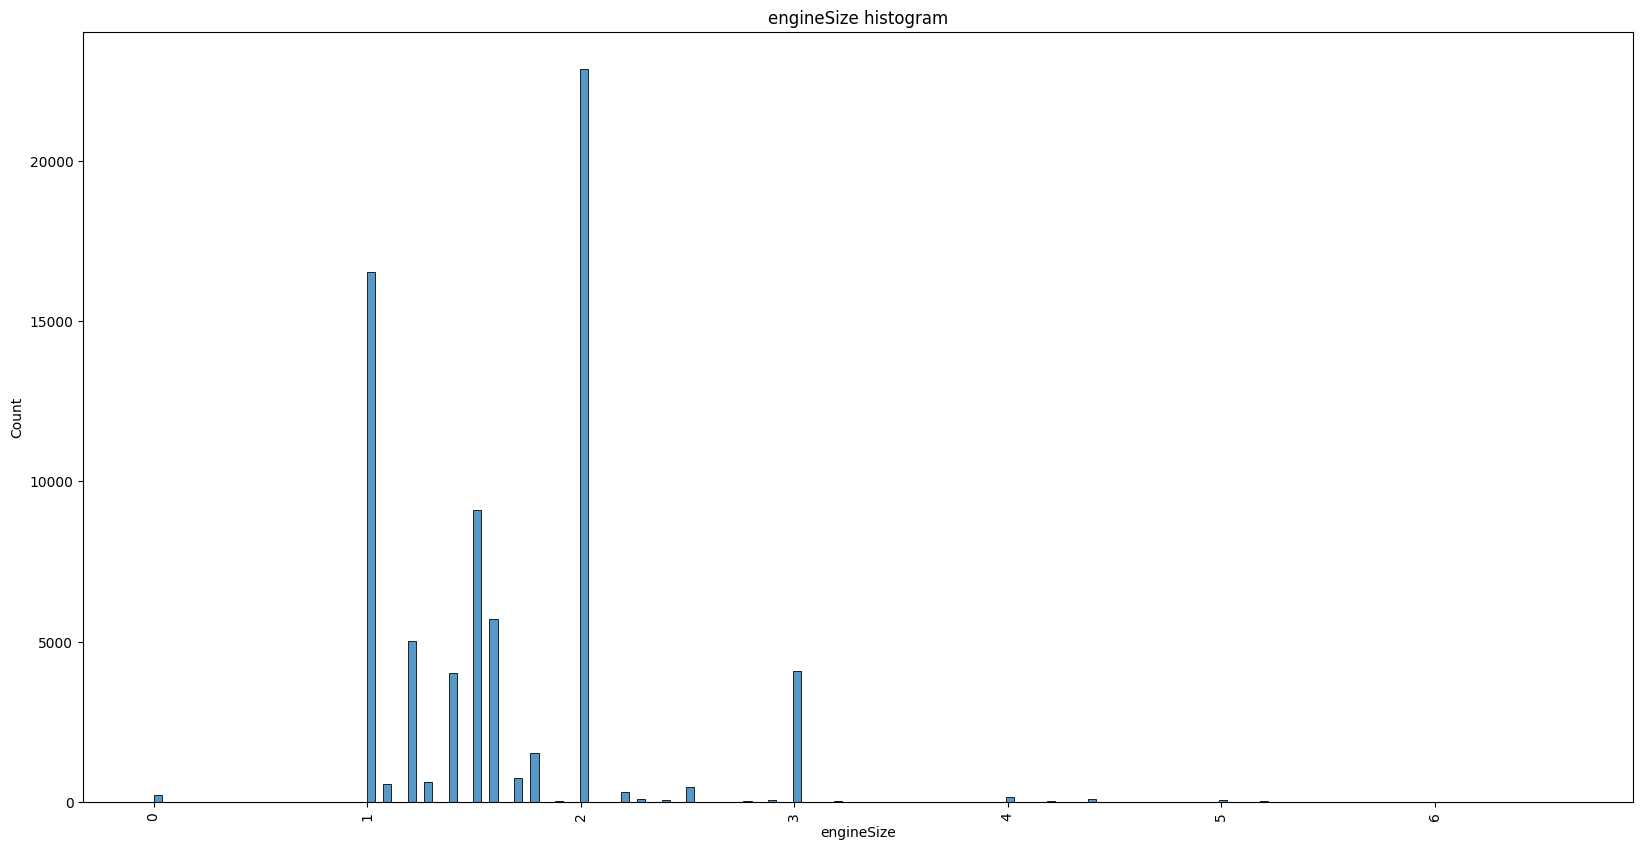

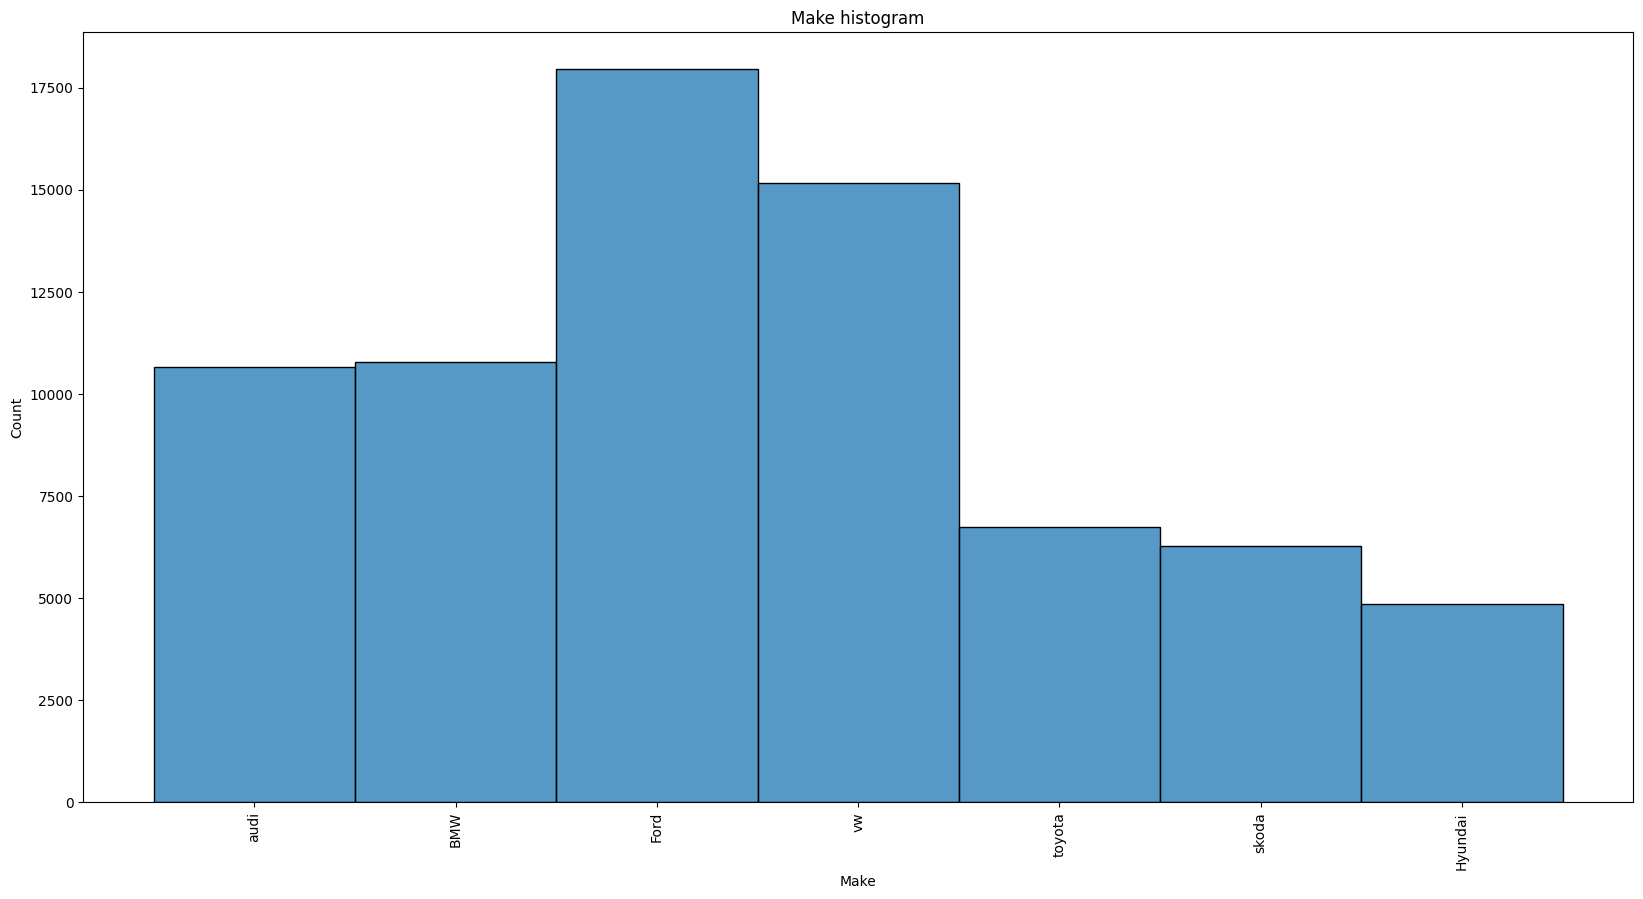

In [13]:
for col in data.columns:
    if col == 'model':
        _, ax = plt.subplots(figsize=(30, 10))
    else:
        _, ax = plt.subplots(figsize=(20, 10))
    ax.tick_params(axis='x', rotation=90)
    plt.title(f'{col} histogram')
    sns.histplot(data=data, x=col, ax=ax)
    plt.show()

## transmission VS year

<AxesSubplot: title={'center': 'transmission VS year'}, xlabel='year', ylabel='transmission'>

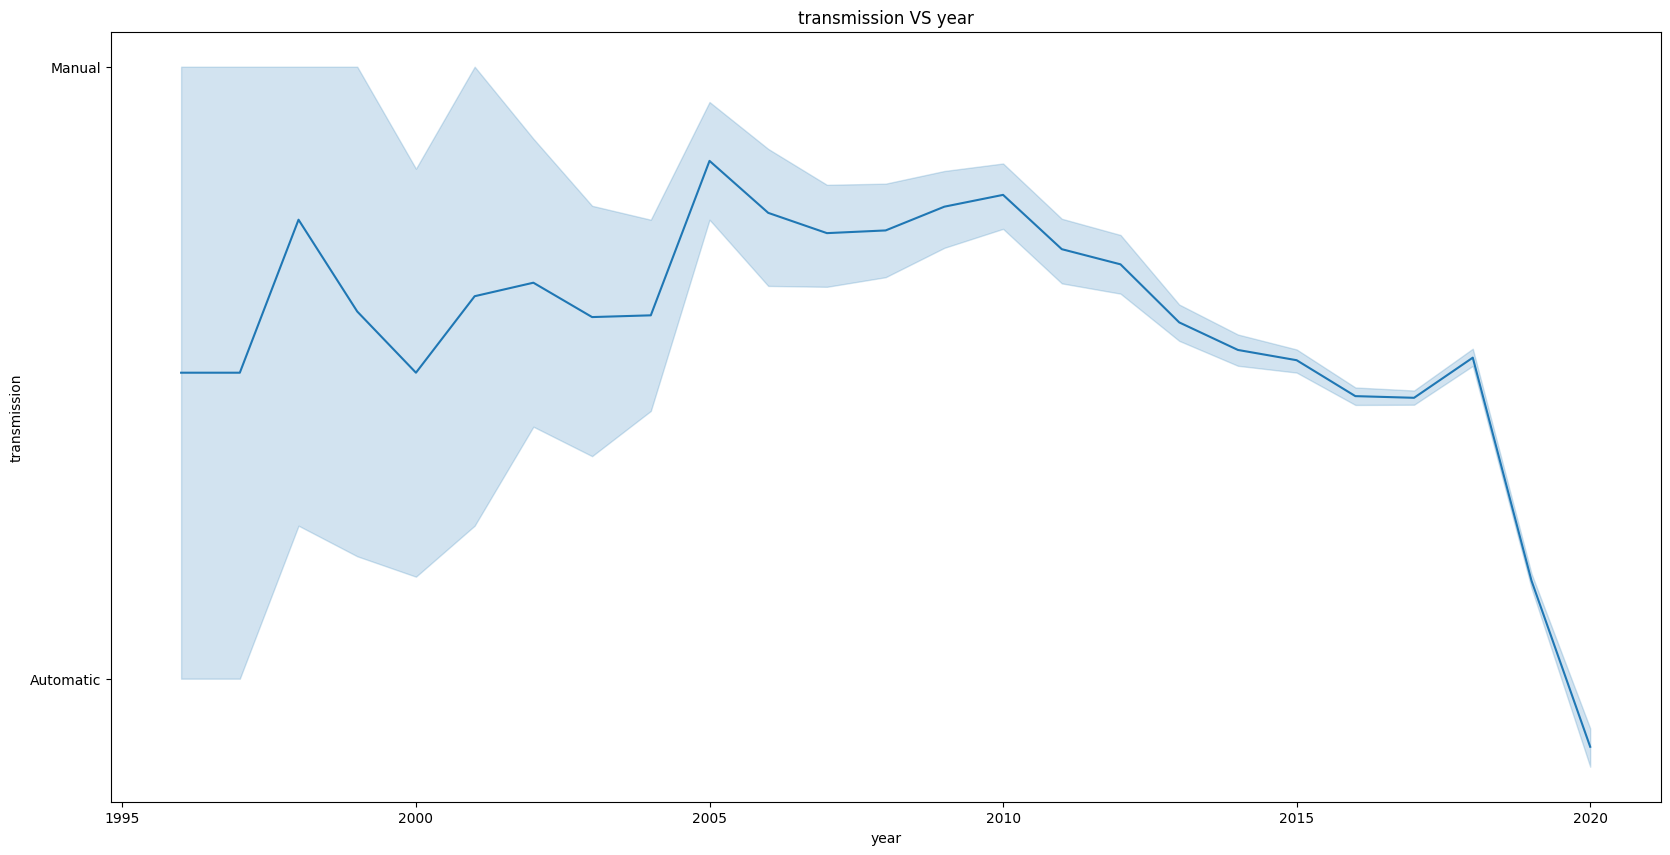

In [14]:
_, ax = plt.subplots(figsize=(20, 10))
plt.title('transmission VS year')
sns.lineplot(data=data, y=data.transmission, x=data.year)

## engineSize VS year

<AxesSubplot: title={'center': 'engineSize VS year'}, xlabel='year', ylabel='engineSize'>

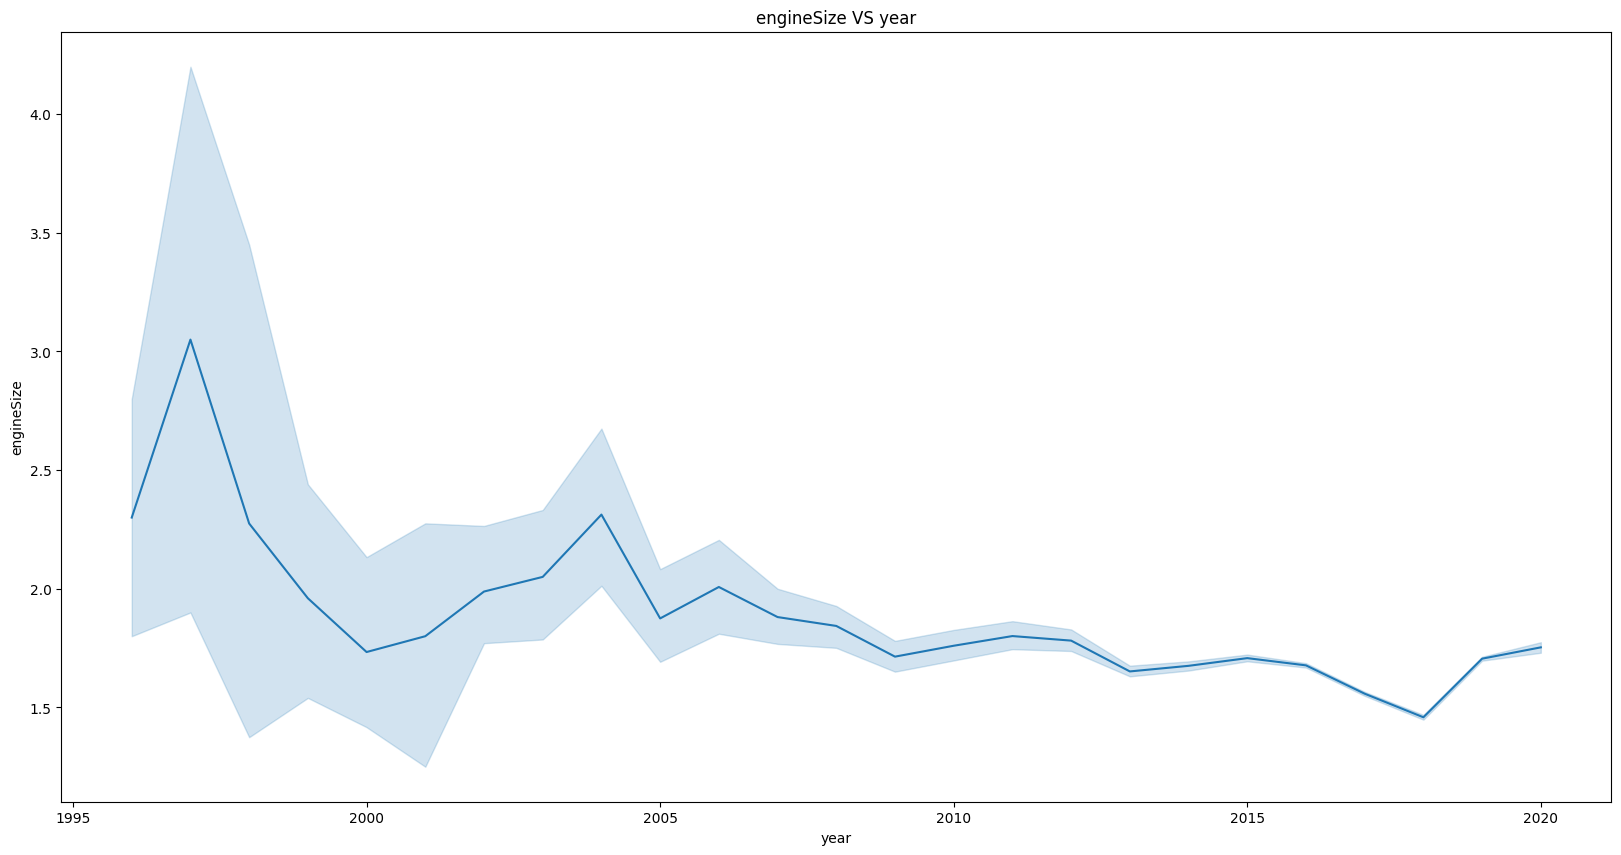

In [15]:
plt.subplots(figsize=(20, 10))
plt.title('engineSize VS year')
sns.lineplot(data=data, y=data.engineSize, x=data.year)

## mileage VS year

<AxesSubplot: title={'center': 'mileage VS year'}, xlabel='year', ylabel='mileage'>

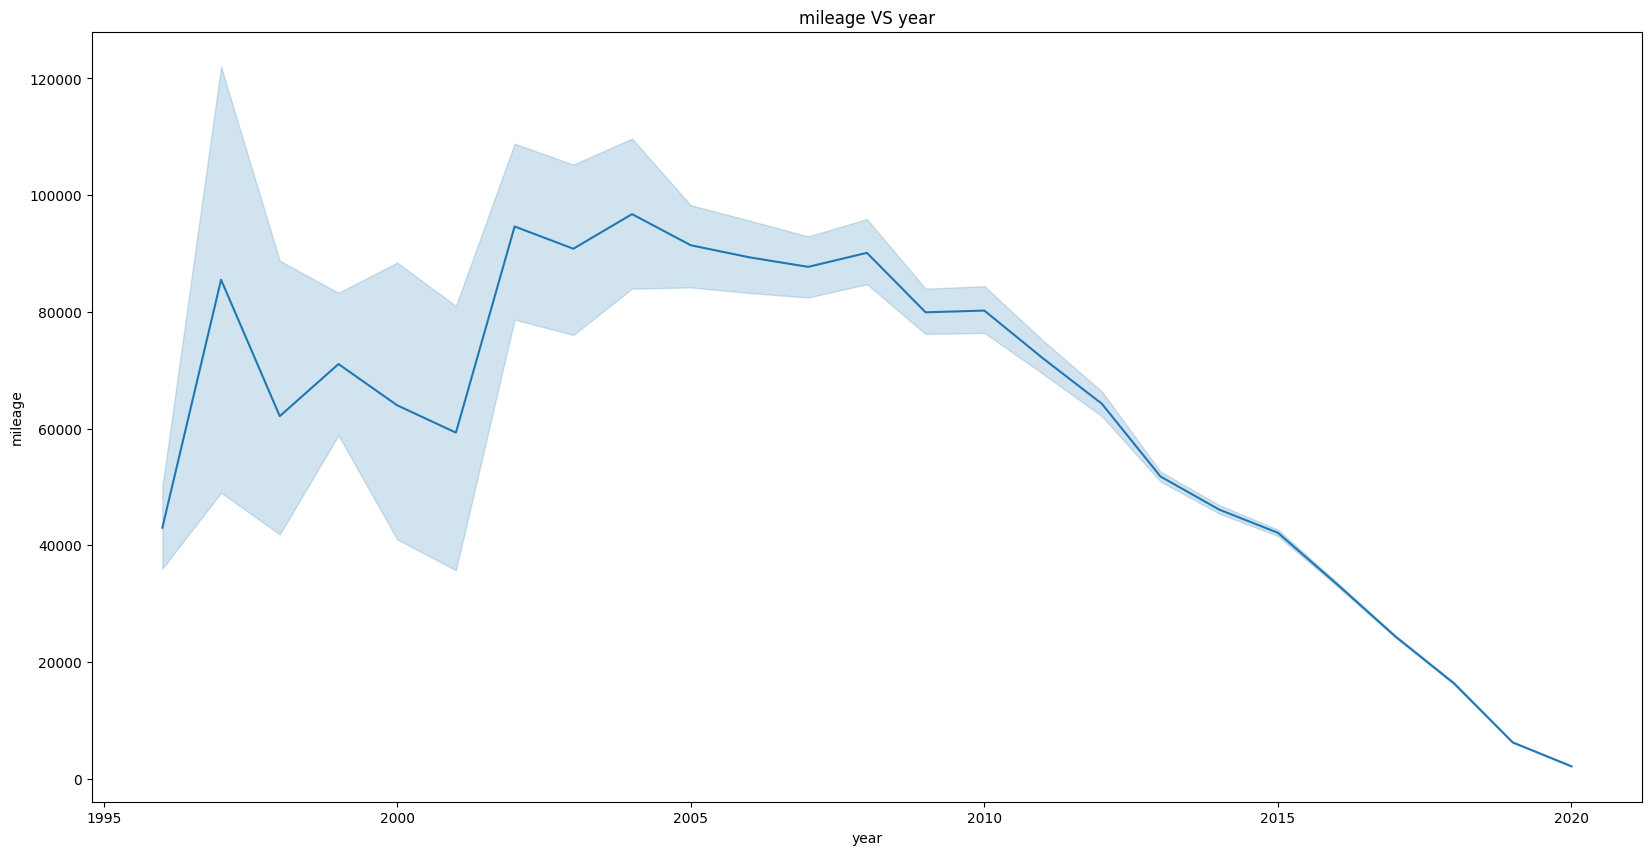

In [16]:
plt.subplots(figsize=(20, 10))
plt.title('mileage VS year')
sns.lineplot(data=data, y=data.mileage, x=data.year)

## price VS year

<AxesSubplot: title={'center': 'price VS year'}, xlabel='year', ylabel='price'>

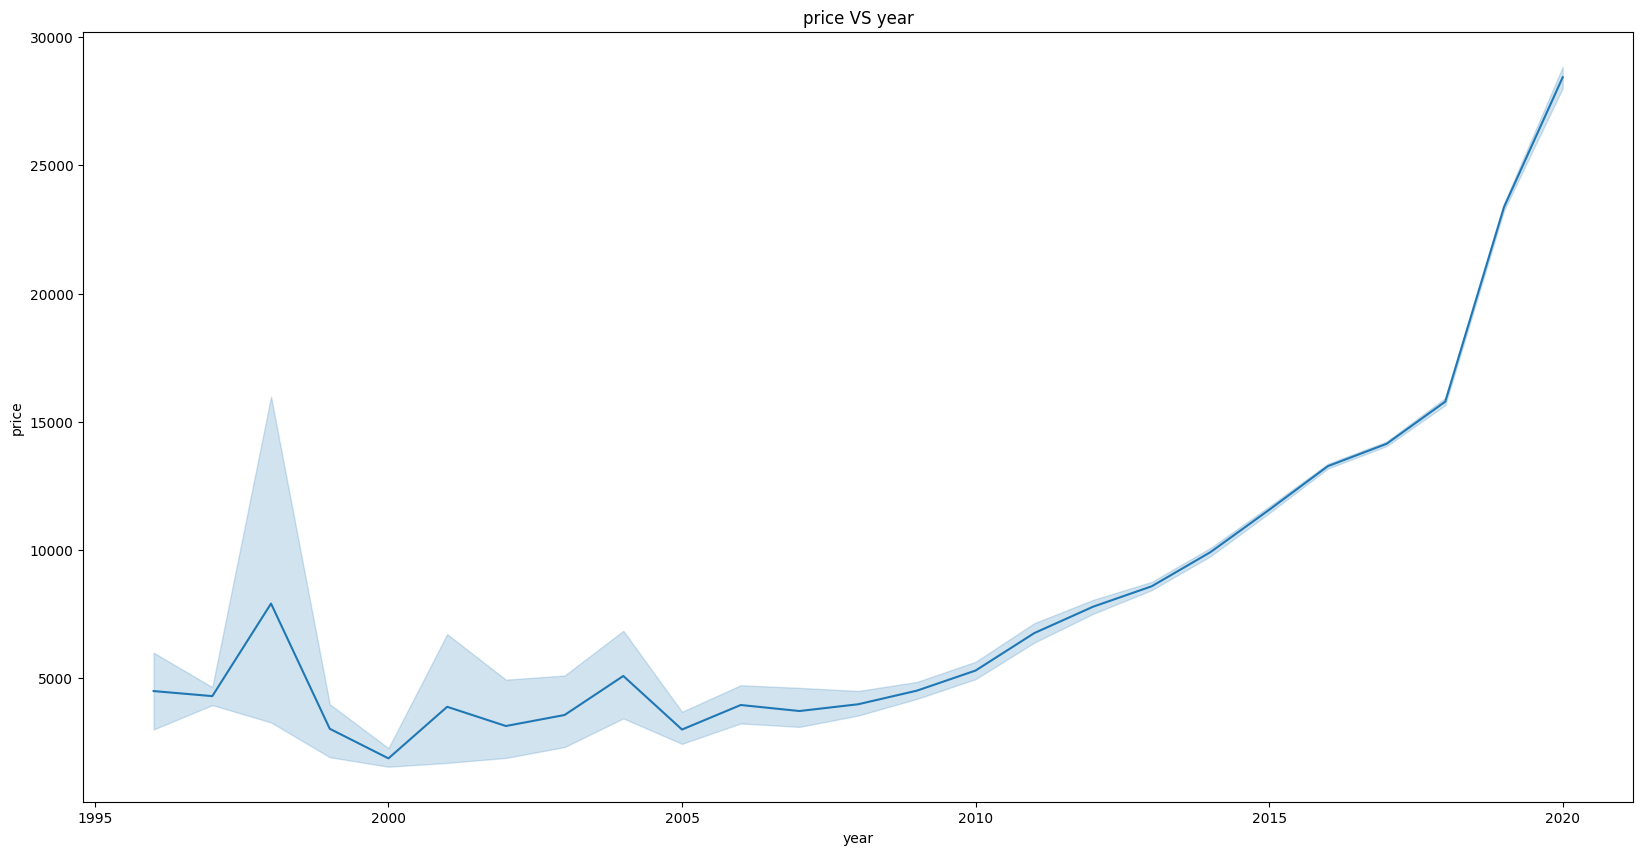

In [17]:
plt.subplots(figsize=(20, 10))
plt.title('price VS year')
sns.lineplot(data=data, y=data.price, x=data.year)

## tax VS year

<AxesSubplot: title={'center': 'tax VS year'}, xlabel='year', ylabel='tax'>

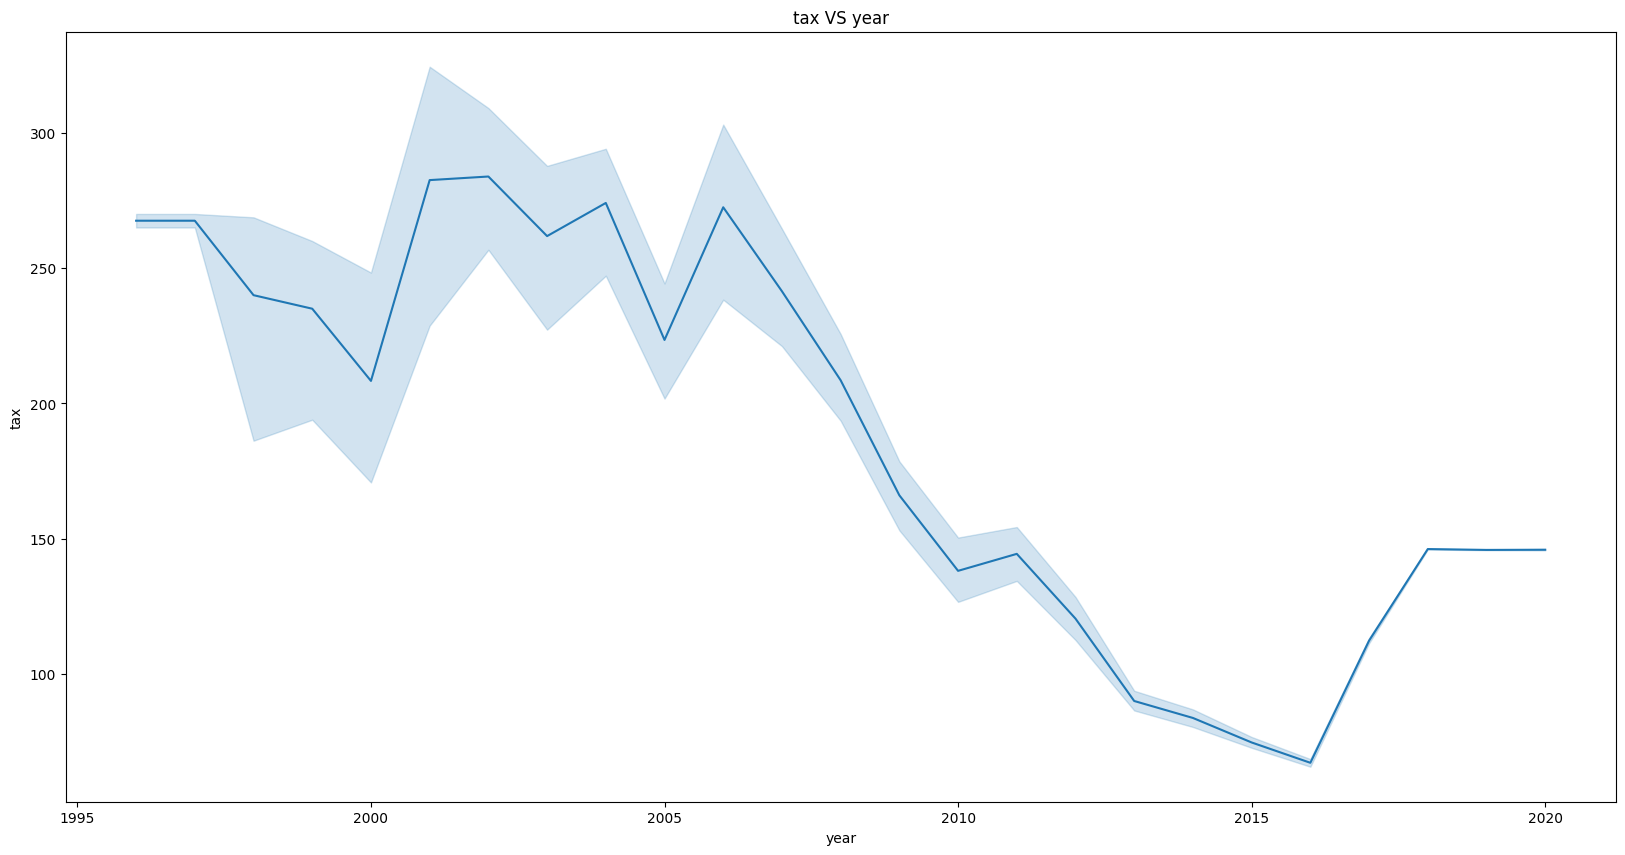

In [18]:
plt.subplots(figsize=(20, 10))
plt.title('tax VS year')
sns.lineplot(data=data, y=data.tax, x=data.year)

# Standardize Function

In [19]:
def standardize(x):
    return (x - np.mean(x)) / np.std(x)

# Encoding

In [20]:
data.model = preprocessing.LabelEncoder().fit_transform(data.model)
data.transmission = preprocessing.LabelEncoder().fit_transform(data.transmission)
data.fuelType = preprocessing.LabelEncoder().fit_transform(data.fuelType)
data.Make = preprocessing.LabelEncoder().fit_transform(data.Make)
data

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,8,2017,12500,1,15735,4,150.0,55.4,1.4,3
1,13,2016,16500,0,36203,0,20.0,64.2,2.0,3
2,8,2016,11000,1,29946,4,30.0,55.4,1.4,3
3,11,2017,16800,0,25952,0,145.0,67.3,2.0,3
4,10,2019,17300,1,1998,4,145.0,49.6,1.0,3
...,...,...,...,...,...,...,...,...,...,...
72430,56,2016,8680,1,25906,0,0.0,78.4,1.6,2
72431,57,2015,7830,1,59508,0,30.0,65.7,1.7,2
72432,54,2017,6830,1,13810,4,20.0,60.1,1.0,2
72433,126,2018,13994,1,23313,4,145.0,44.8,1.6,2


# Standardization

In [21]:
data.mileage = standardize(data.mileage)
data.mpg = standardize(data.mpg)
data.tax = standardize(data.tax)
data

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,8,2017,12500,1,-0.348853,4,0.515989,-0.026439,1.4,3
1,13,2016,16500,0,0.610673,0,-1.513830,0.487752,2.0,3
2,8,2016,11000,1,0.317349,4,-1.357690,-0.026439,1.4,3
3,11,2017,16800,0,0.130113,0,0.437919,0.668887,2.0,3
4,10,2019,17300,1,-0.992834,4,0.437919,-0.365337,1.0,3
...,...,...,...,...,...,...,...,...,...,...
72430,56,2016,8680,1,0.127956,0,-1.826110,1.317469,1.6,2
72431,57,2015,7830,1,1.703195,0,-1.357690,0.575398,1.7,2
72432,54,2017,6830,1,-0.439096,4,-1.513830,0.248186,1.0,2
72433,126,2018,13994,1,0.006398,4,0.437919,-0.645805,1.6,2


# Describe Data after Standardization

In [22]:
data.describe()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
count,72435.000000,72435.000000,72435.000000,72435.000000,7.243500e+04,72435.000000,7.243500e+04,7.243500e+04,72435.000000,72435.000000
mean,58.453855,2017.073666,16580.158708,1.230358,1.726452e-17,2.319431,6.984281e-17,5.446170e-16,1.635650,2.890702
std,41.229274,2.101252,9299.028754,0.994658,1.000007e+00,1.930699,1.000007e+00,1.000007e+00,0.561535,2.174535
min,0.000000,1996.000000,495.000000,0.000000,-1.086452e+00,0.000000,-1.826110e+00,-3.245974e+00,0.000000,0.000000
25%,25.000000,2016.000000,10175.000000,1.000000,-7.488510e-01,0.000000,-1.357690e+00,-4.646695e-01,1.200000,1.000000
50%,49.000000,2017.000000,14495.000000,1.000000,-2.646580e-01,4.000000,4.379195e-01,-2.643876e-02,1.600000,3.000000
75%,85.000000,2019.000000,20361.000000,1.000000,4.346877e-01,4.000000,4.379195e-01,4.059489e-01,2.000000,5.000000
max,145.000000,2020.000000,145000.000000,3.000000,1.405552e+01,4.000000,7.230009e+00,2.424570e+01,6.600000,6.000000


# Split Data into X and y

In [23]:
data = shuffle(data)
y = data.price
data.drop('price', axis=1, inplace=True)
X = data

## Features

In [24]:
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,Make
68606,55,2013,1,0.460518,4,-1.357690,0.102109,1.2,2
7021,87,2016,3,-0.008744,0,1.296689,-0.511414,2.0,3
47464,82,2019,1,-0.898982,4,0.515989,-0.207574,1.0,6
61587,41,2019,1,-0.986178,4,0.437919,0.324146,1.0,4
16387,132,2017,0,0.090172,0,0.437919,0.102109,2.0,0
...,...,...,...,...,...,...,...,...,...
21509,70,2018,1,0.293065,0,0.437919,-0.090713,1.5,1
123,11,2014,1,0.384386,0,0.125640,0.178069,2.0,3
57689,20,2014,0,0.479317,2,-1.826110,0.966884,1.8,5
29494,70,2017,1,-0.357198,0,0.437919,0.248186,2.0,1


## Labels

In [25]:
y

68606     4495
7021     22000
47464    13995
61587    11883
16387    21500
         ...  
21509    16495
123      11700
57689    11495
29494    15900
34366    10499
Name: price, Length: 72435, dtype: int64

# Linear Regression Models

Degree 1
R2 Score: 0.73
Mean Squared Error: 24030804.78
Mean Absolute Error: 3269.56
Mean Absolute Percentage Error: 0.24
Accuracy: 0.73


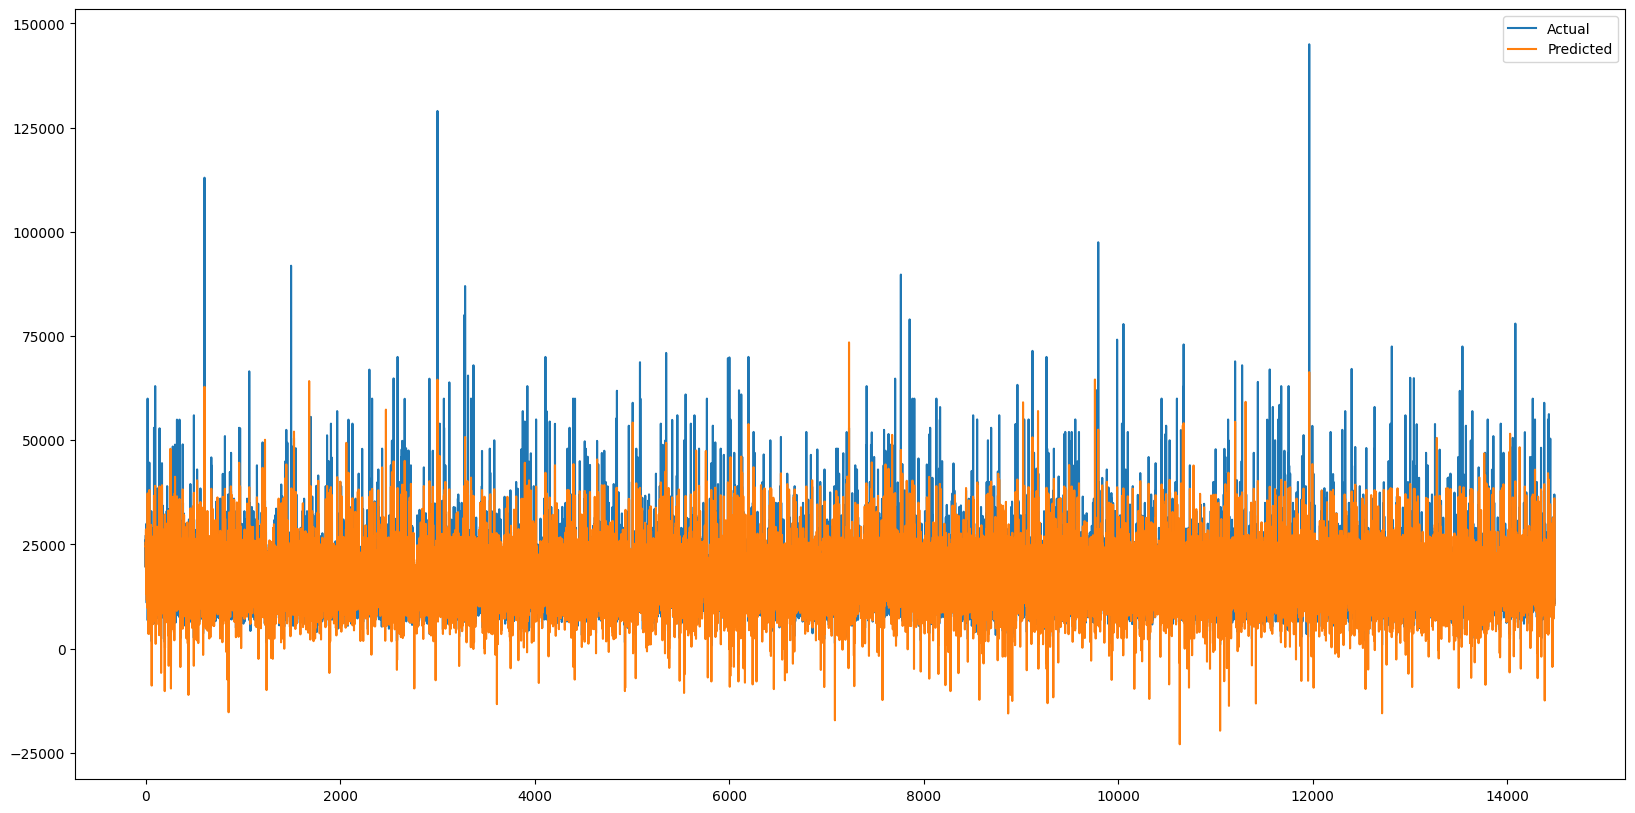



Degree 2
R2 Score: 0.83
Mean Squared Error: 14857060.21
Mean Absolute Error: 2576.29
Mean Absolute Percentage Error: 0.17
Accuracy: 0.83


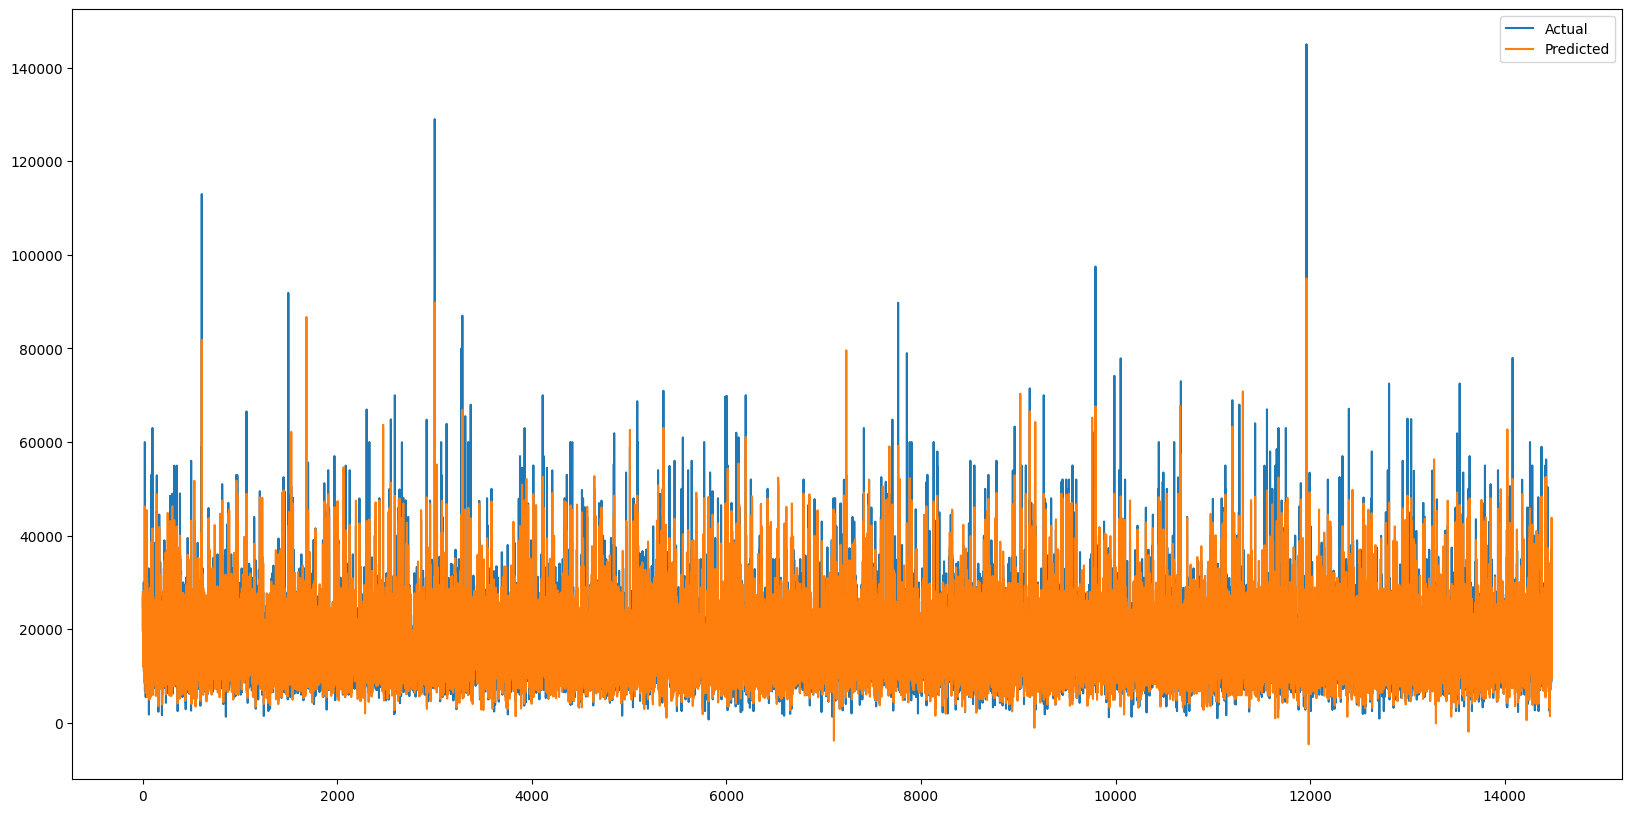



Degree 3
R2 Score: 0.88
Mean Squared Error: 10961737.18
Mean Absolute Error: 2174.25
Mean Absolute Percentage Error: 0.14
Accuracy: 0.88


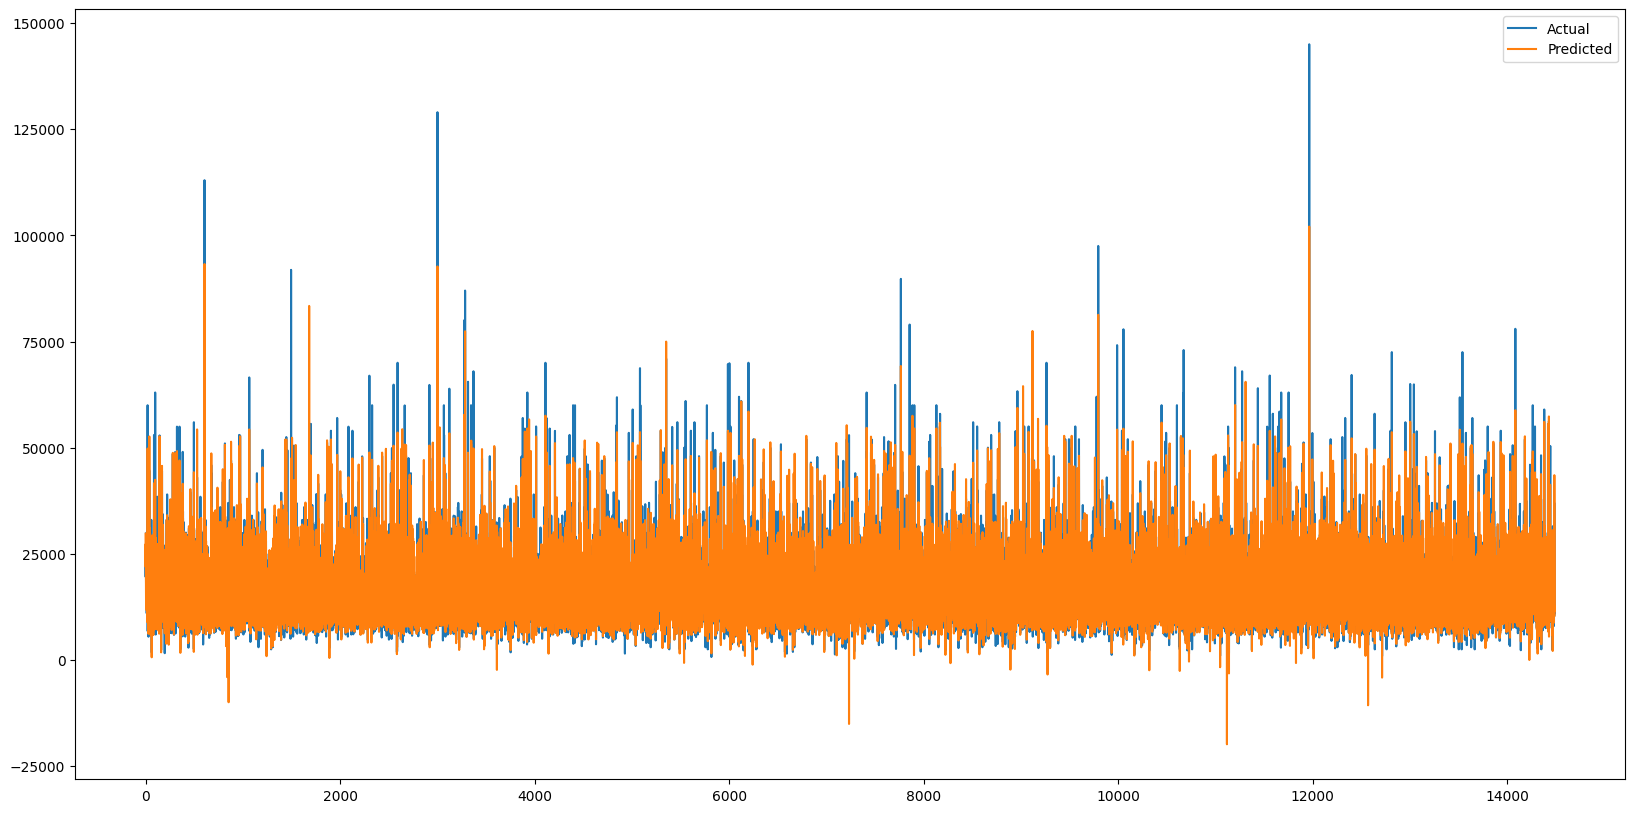



Degree 4
R2 Score: 0.9
Mean Squared Error: 9189432.33
Mean Absolute Error: 1892.55
Mean Absolute Percentage Error: 0.13
Accuracy: 0.9


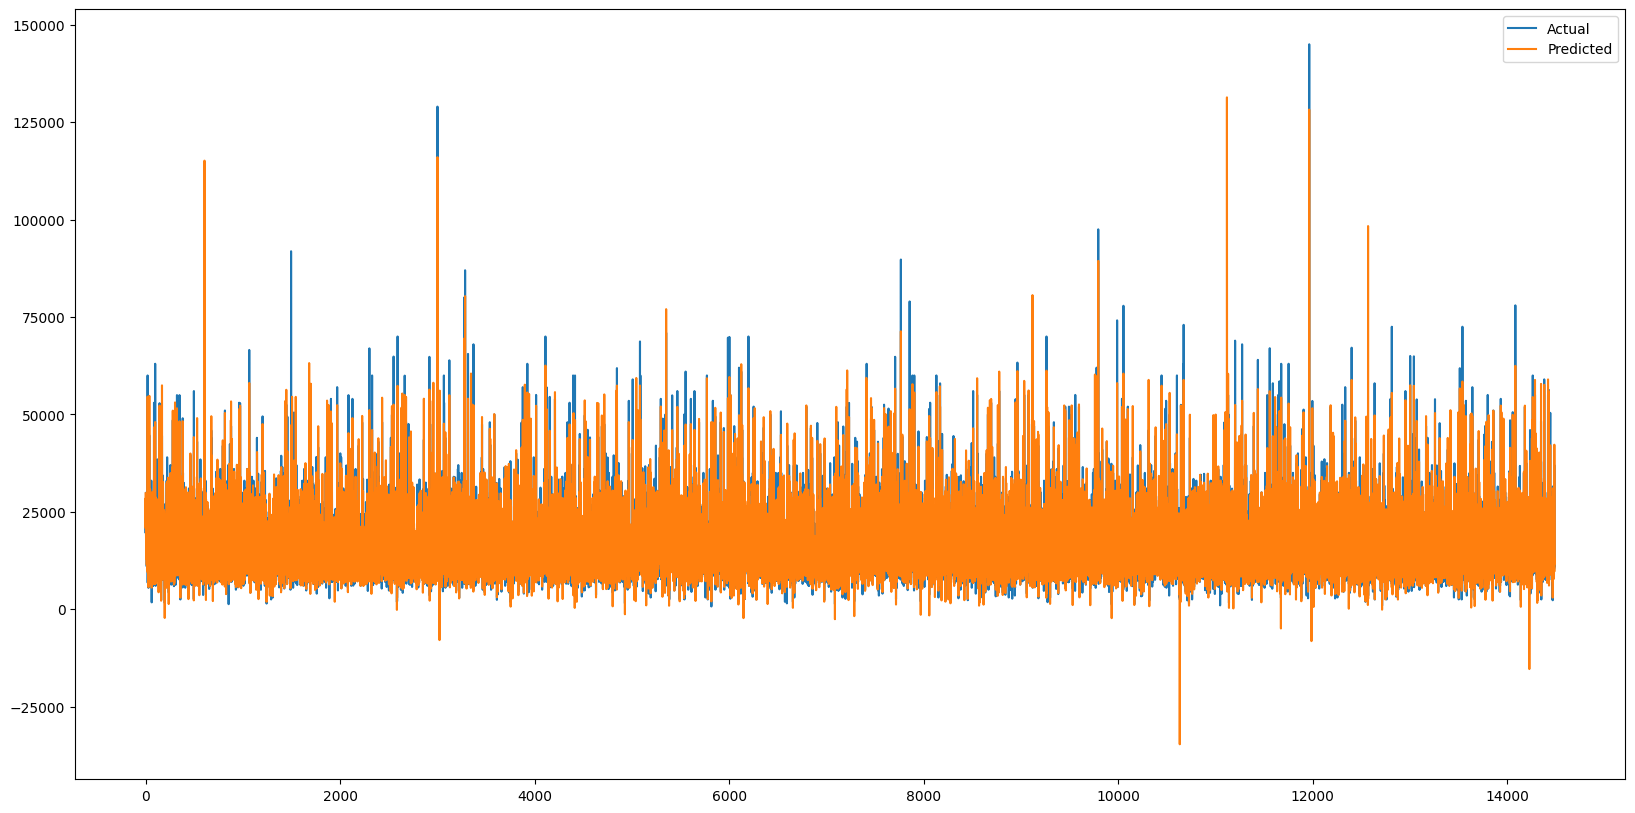



Degree 5
R2 Score: 0.09
Mean Squared Error: 80203854.32
Mean Absolute Error: 1826.58
Mean Absolute Percentage Error: 0.13
Accuracy: 0.09


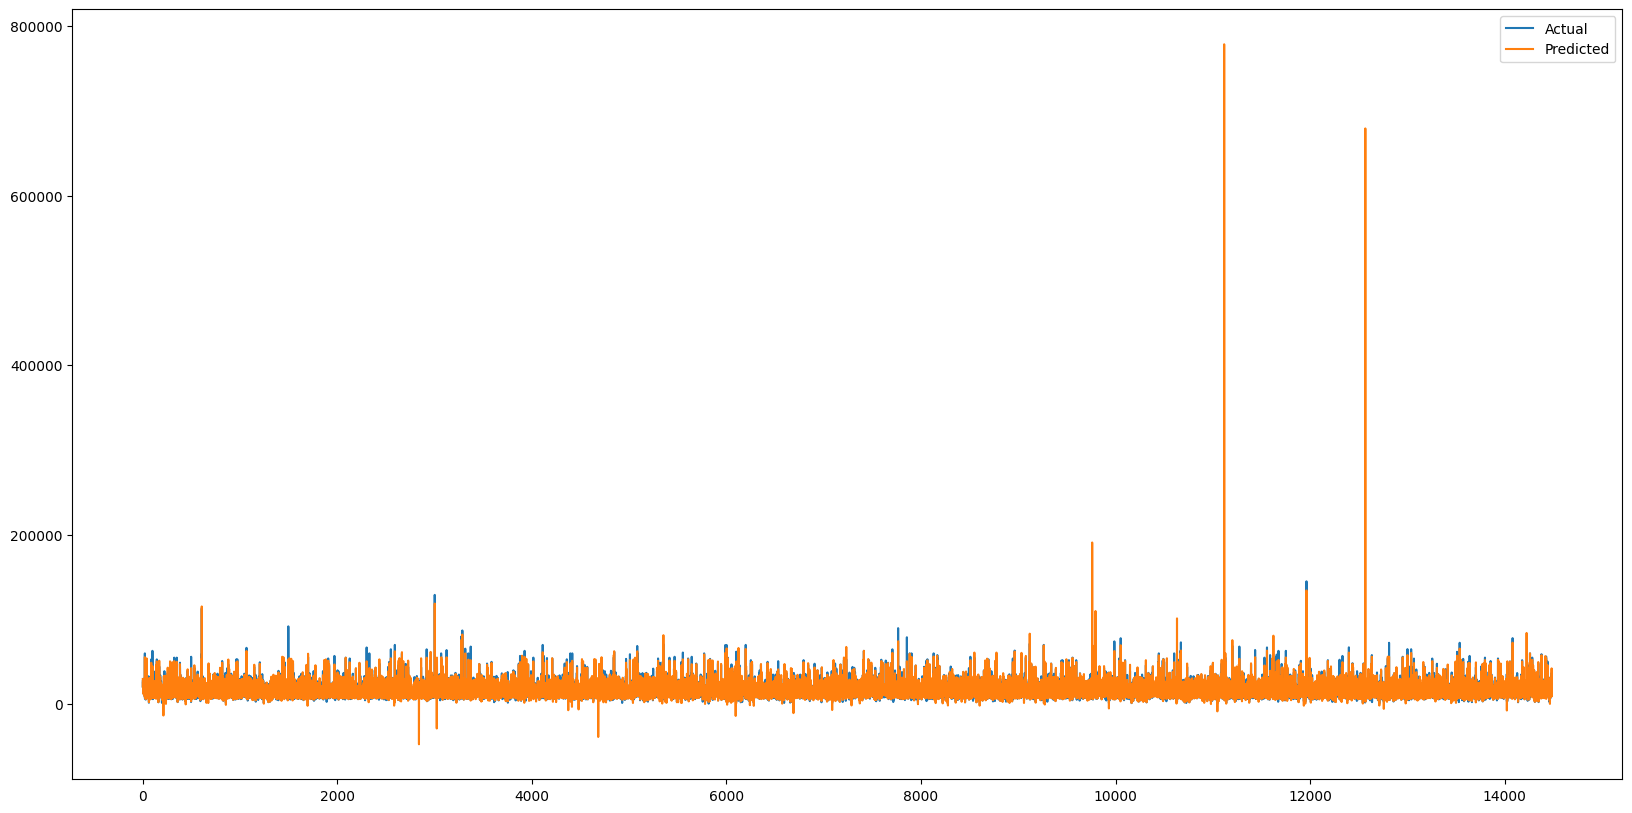



Degree 6
R2 Score: -16.63
Mean Squared Error: 1549271167.21
Mean Absolute Error: 2037.27
Mean Absolute Percentage Error: 0.13
Accuracy: -16.63


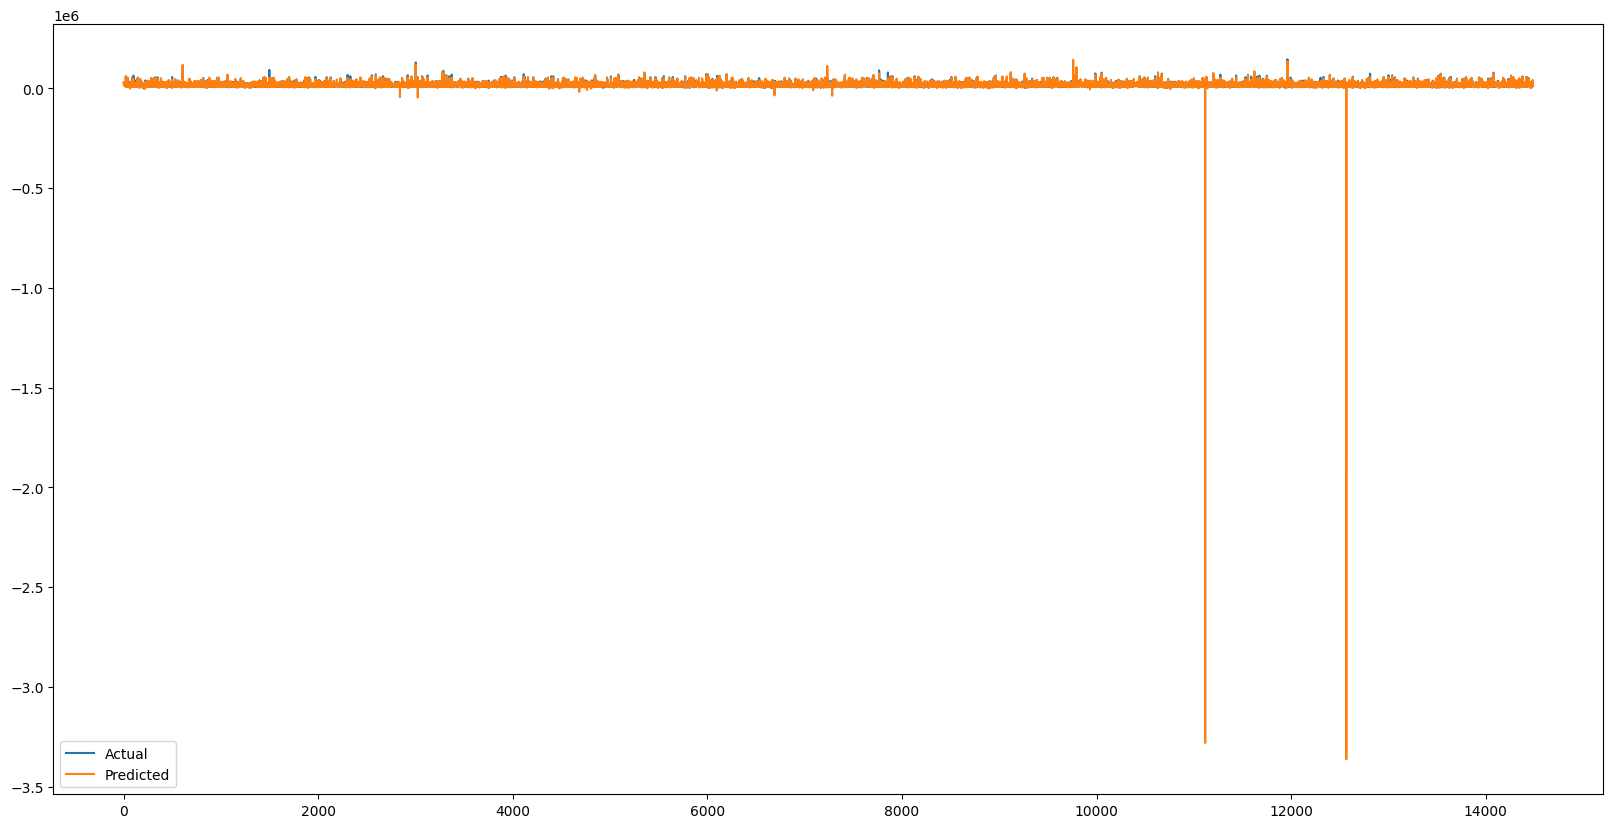

In [26]:
r2 = []
mse = []
mae = []
mape = []
accuracy = []
for i in range(1, 7):
    poly = PolynomialFeatures(degree=i)
    X_poly = poly.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=0)
    Model = LinearRegression()
    Model.fit(X_train, y_train)
    y_pred = Model.predict(X_test)

    r2.append(round(r2_score(y_test, y_pred), 2))
    mse.append(round(mean_squared_error(y_test, y_pred), 2))
    mae.append(round(mean_absolute_error(y_test, y_pred), 2))
    mape.append(round(mean_absolute_percentage_error(y_test, y_pred), 2))
    accuracy.append(round(Model.score(X_test, y_test), 2))

    print(f'Degree {i}')
    print(f'R2 Score: {r2[-1]}')
    print(f'Mean Squared Error: {mse[-1]}')
    print(f'Mean Absolute Error: {mae[-1]}')
    print(f'Mean Absolute Percentage Error: {mape[-1]}')
    print(f'Accuracy: {accuracy[-1]}')

    Y_Test_Pred = pd.DataFrame({"Y_Test": y_test, "Y_Pred": y_pred})
    Y_Test_Pred = Y_Test_Pred.reset_index()
    plt.figure(figsize=(20, 10))
    Y_Test_Pred = Y_Test_Pred.drop(["index"], axis=1)
    plt.plot(Y_Test_Pred)
    plt.legend(["Actual", "Predicted"])
    plt.show()
    print()
    print()

# Plot R2 Score, Mean Squared Error, Mean Absolute Error and Accuracy

## Plot without standardization

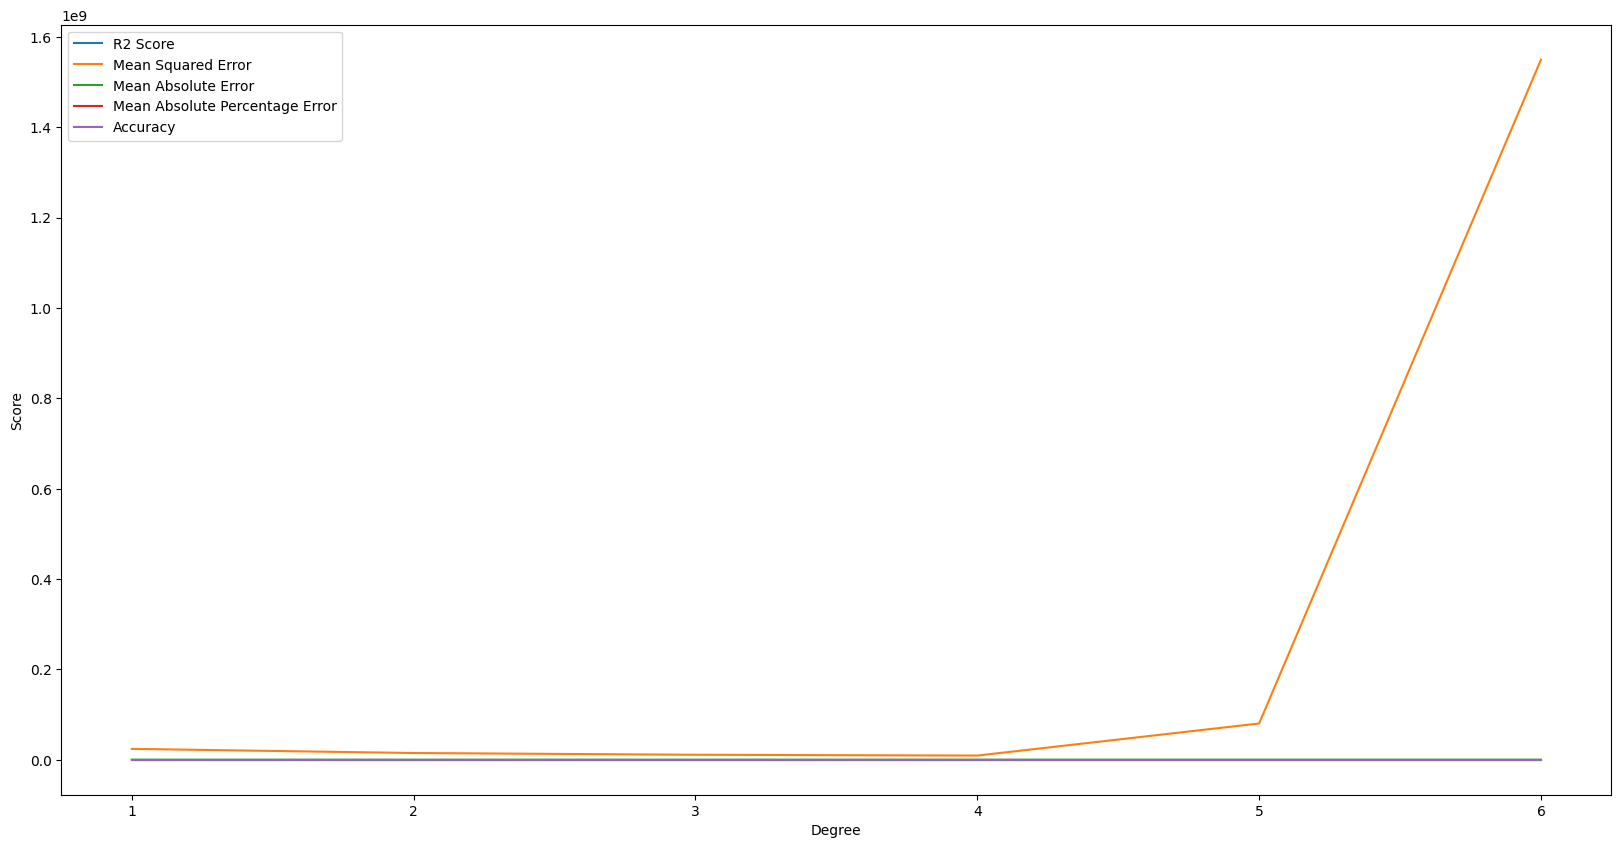

In [27]:
r2 = np.array(r2)
mse = np.array(mse)
mae = np.array(mae)
mape = np.array(mape)
_, ax = plt.subplots(figsize=(20, 10))
ax.plot(np.linspace(1, 6, 6), r2, label='R2 Score')
ax.plot(np.linspace(1, 6, 6), mse, label='Mean Squared Error')
ax.plot(np.linspace(1, 6, 6), mae, label='Mean Absolute Error')
ax.plot(np.linspace(1, 6, 6), mape, label='Mean Absolute Percentage Error')
ax.plot(np.linspace(1, 6, 6), accuracy, label='Accuracy')
ax.set_xlabel('Degree')
ax.set_ylabel('Score')
plt.legend()
plt.show()

## Plot with standardization

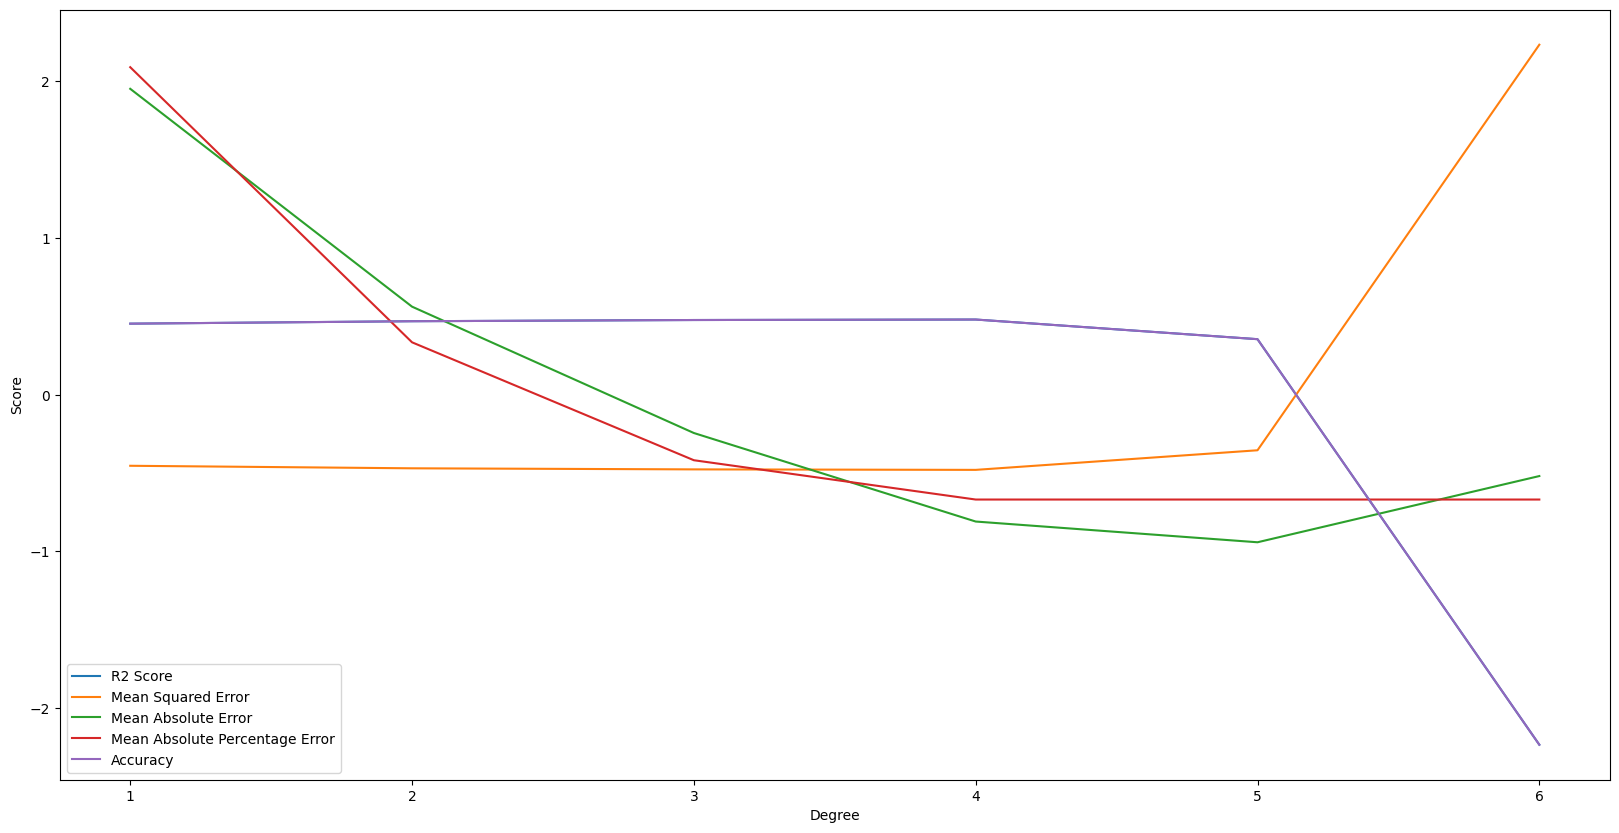

In [28]:
r2 = standardize(r2)
mse = standardize(mse)
mae = standardize(mae)
mape = standardize(mape)
accuracy = standardize(accuracy)
_, ax = plt.subplots(figsize=(20, 10))
ax.plot(np.linspace(1, 6, 6), r2, label='R2 Score')
ax.plot(np.linspace(1, 6, 6), mse, label='Mean Squared Error')
ax.plot(np.linspace(1, 6, 6), mae, label='Mean Absolute Error')
ax.plot(np.linspace(1, 6, 6), mape, label='Mean Absolute Percentage Error')
ax.plot(np.linspace(1, 6, 6), accuracy, label='Accuracy')
ax.set_xlabel('Degree')
ax.set_ylabel('Score')
plt.legend()
plt.show()